### Install libraries

In [2]:
!pip install openpyxl

In [3]:
!pip install arch

### Load Libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import yfinance as yf
import openpyxl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor
from arch import arch_model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### Configuration & Data Loading

In [7]:
RAW_DATA_PATH = "data/raw_data.csv"
CPI_PATH = "data/cpi.xlsx"
KIBOR_PATH = "data/kibor_rate.csv"

INITIAL_CAPITAL = 100000
BUY_THRESHOLD = 0.05
SELL_THRESHOLD = -0.05

RANDOM_STATE = 42

# Annual GDP growth values provided by the user
GDP_BY_YEAR = {
    2021: 6.513885759,
    2022: 4.778106869,
    2023: -0.414936,
    2024: 3.048982873,
    2025: 2.70
}


### Helper Functions & Feature Engineering

In [9]:
def clean_numeric(val):
    """
    Converts strings like '45,000', '2.3M', '5.4%', etc. into numeric values.
    """
    if pd.isna(val):
        return np.nan

    if isinstance(val, str):
        val = val.replace(",", "").replace("%", "").strip()

        if val == "":
            return np.nan

        multiplier_map = {"K": 1e3, "M": 1e6, "B": 1e9}
        for suffix, multiplier in multiplier_map.items():
            if val.endswith(suffix):
                try:
                    return float(val[:-1]) * multiplier
                except ValueError:
                    return np.nan

        try:
            return float(val)
        except ValueError:
            return np.nan

    return val

In [10]:
def fetch_yfinance_close_series(ticker, start_date, end_date, output_col_name):
    """
    Pulls daily close prices from Yahoo Finance and returns a Date/Close dataframe.
    """
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date + pd.Timedelta(days=5),
        auto_adjust=False,
        progress=False
    )

    if data.empty:
        raise RuntimeError(
            f"Yahoo Finance returned no data for {ticker}. "
            f"Check internet access and ticker validity."
        )

    if isinstance(data.columns, pd.MultiIndex):
        close_series = data["Close"].iloc[:, 0]
    else:
        close_series = data["Close"]

    out = close_series.reset_index()
    out.columns = ["Date", output_col_name]
    out["Date"] = pd.to_datetime(out["Date"])
    return out


In [11]:
def prepare_cpi_monthly(cpi_path):
    """
    Converts the CPI workbook from wide format into monthly long format.
    Drops annual and quarterly fields and keeps monthly CPI values only.

    Output columns:
    - cpi_month_key: monthly merge key
    - cpi: CPI level for the month
    """
    cpi_wide = pd.read_excel(cpi_path)

    row = cpi_wide.iloc[0].to_dict()
    monthly_rows = []

    for key, value in row.items():
        if isinstance(key, str) and "-M" in key:
            year_str, month_str = key.split("-M")
            month_start = pd.Timestamp(f"{year_str}-{month_str}-01")

            monthly_rows.append({
                "cpi_month_key": pd.Period(month_start, freq="M"),
                "cpi": pd.to_numeric(value, errors="coerce")
            })

    cpi_monthly = (
        pd.DataFrame(monthly_rows)
        .sort_values("cpi_month_key")
        .reset_index(drop=True)
    )

    return cpi_monthly

In [12]:
def prepare_kibor(kibor_path):
    """
    Loads daily KIBOR data and standardizes the column names.
    """
    kibor = pd.read_csv(kibor_path)
    kibor["Date"] = pd.to_datetime(kibor["Observation Date"], format="%d-%b-%y", errors="coerce")
    kibor["kibor_rate"] = pd.to_numeric(kibor["Observation Value"], errors="coerce")
    kibor = kibor[["Date", "kibor_rate"]].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return kibor

In [13]:
def compute_rsi(series, period=14):
    """
    Computes Relative Strength Index.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(com=period - 1, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [14]:
def days_since_rolling_high(close_series, window):
    """
    Number of trading days since the most recent rolling-window high.
    """
    return close_series.rolling(window, min_periods=window).apply(
        lambda x: (len(x) - 1) - np.argmax(x),
        raw=True
    )

In [15]:
def add_drawdown_features(df, window):
    """
    Adds rolling drawdown features for a given lookback window.
    """
    # Rolling peak close over the last {window} trading days ending at t
    df[f"rolling_max_close_{window}"] = df["Close"].rolling(window, min_periods=window).max()

    # Current drawdown from the rolling peak; values are <= 0
    df[f"drawdown_{window}"] = df["Close"] / df[f"rolling_max_close_{window}"] - 1

    # Worst drawdown seen inside the same rolling window
    df[f"max_drawdown_{window}"] = df[f"drawdown_{window}"].rolling(window, min_periods=window).min()

    # Trading days since the most recent high in the rolling window
    df[f"days_since_high_{window}"] = days_since_rolling_high(df["Close"], window)

    return df

In [16]:
def add_technical_features(df):
    """
    Adds technical, volatility, regime, liquidity, and drawdown features.
    Uses only information available as of date t.
    """
    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]
    prev_close = df["prev_close"]

    # Simple moving averages over short, medium, and long windows
    for w in [10, 20, 50, 200]:
        df[f"SMA_{w}"] = close.rolling(w, min_periods=w).mean()

    # Exponential moving averages that weight recent prices more heavily
    for w in [10, 20, 50]:
        df[f"EMA_{w}"] = close.ewm(span=w, adjust=False, min_periods=w).mean()

    # Binary bull regime flag based on 50-day vs 200-day simple moving average
    df["Golden_Cross"] = (df["SMA_50"] > df["SMA_200"]).astype(float)

    # Binary short-term momentum crossover flag based on 10-day vs 20-day EMA
    df["EMA_crossover"] = (df["EMA_10"] > df["EMA_20"]).astype(float)

    # 14-day RSI momentum oscillator
    df["RSI_14"] = compute_rsi(close, period=14)

    # Overbought flag when RSI is above 70
    df["RSI_OB"] = (df["RSI_14"] > 70).astype(float)

    # Oversold flag when RSI is below 30
    df["RSI_OS"] = (df["RSI_14"] < 30).astype(float)

    # MACD line using 12-day EMA minus 26-day EMA
    df["MACD_Line"] = close.ewm(span=12, adjust=False, min_periods=12).mean() - \
                      close.ewm(span=26, adjust=False, min_periods=26).mean()

    # MACD signal line using 9-day EMA of MACD
    df["MACD_Signal"] = df["MACD_Line"].ewm(span=9, adjust=False, min_periods=9).mean()

    # MACD histogram measuring MACD minus signal
    df["MACD_Hist"] = df["MACD_Line"] - df["MACD_Signal"]

    # 5-day rate of change in percent
    df["ROC_5"] = close.pct_change(5) * 100

    # 20-day Bollinger middle band
    bb_mid = close.rolling(20, min_periods=20).mean()

    # 20-day Bollinger rolling standard deviation
    bb_std = close.rolling(20, min_periods=20).std()

    # Upper Bollinger band
    df["BB_Upper"] = bb_mid + 2 * bb_std

    # Lower Bollinger band
    df["BB_Lower"] = bb_mid - 2 * bb_std

    # Middle Bollinger band
    df["BB_Middle"] = bb_mid

    # Relative Bollinger band width as a volatility measure
    df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / bb_mid

    # Position of close within Bollinger bands
    df["BB_Pct"] = (close - df["BB_Lower"]) / (df["BB_Upper"] - df["BB_Lower"]).replace(0, np.nan)

    # True Range using current high-low and gaps from previous close
    df["True_Range"] = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    # 14-day ATR as smoothed true range
    df["ATR_14"] = df["True_Range"].ewm(span=14, adjust=False, min_periods=14).mean()

    # ATR scaled by price in percent
    df["ATR_Pct"] = df["ATR_14"] / close * 100

    # 20-day historical volatility annualized from log returns
    df["HV_20"] = np.log(close / prev_close).rolling(20, min_periods=20).std() * np.sqrt(252) * 100

    # 20-day average volume
    df["Volume_SMA_20"] = volume.rolling(20, min_periods=20).mean()

    # Volume-derived feature: today's volume relative to 20-day average volume
    df["Vol_Ratio"] = volume / df["Volume_SMA_20"]

    # 20-day rolling median volume for more robust volume regime detection
    df["Volume_Median_20"] = volume.rolling(20, min_periods=20).median()

    # Volume-derived feature: current volume divided by 20-day rolling median volume
    df["Volume_Regime"] = volume / df["Volume_Median_20"]

    # Trend regime defined as distance between 20-day and 50-day moving averages scaled by 50-day average
    df["Trend_Regime"] = (df["SMA_20"] - df["SMA_50"]) / df["SMA_50"]

    # Volume-derived feature: liquidity stress defined as true range relative to current volume
    df["Liquidity_Stress"] = df["True_Range"] / volume.replace(0, np.nan)

    # 5-day rolling average KIBOR
    df["kibor_rate_ma_5"] = df["kibor_rate"].rolling(5, min_periods=1).mean()

    # 20-day rolling average KIBOR
    df["kibor_rate_ma_20"] = df["kibor_rate"].rolling(20, min_periods=1).mean()

    # 5-day change in KIBOR rate
    df["kibor_rate_change_5"] = df["kibor_rate"] - df["kibor_rate"].shift(5)

    # 20-day change in KIBOR rate
    df["kibor_rate_change_20"] = df["kibor_rate"] - df["kibor_rate"].shift(20)

    # Lagged close prices for autoregressive structure
    for lag in [1, 2, 3, 5, 10]:
        df[f"close_lag_{lag}"] = close.shift(lag)

    # Lagged daily returns for short-term memory in returns
    for lag in [1, 2, 3, 5, 10]:
        df[f"return_lag_{lag}"] = df["daily_return"].shift(lag)

    # Drawdown features over 63 trading days
    df = add_drawdown_features(df, 63)

    # Drawdown features over 252 trading days
    df = add_drawdown_features(df, 252)

    return df

In [17]:
def calculate_vif(dataframe, feature_list):
    """
    Computes VIF for a list of numeric features.
    """
    X = dataframe[feature_list].copy()
    X = X.dropna()

    if X.empty or X.shape[1] < 2:
        return pd.DataFrame(columns=["feature", "VIF"])

    vif_df = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    return vif_df

In [18]:
def iterative_vif_filter(dataframe, feature_list, vif_threshold=10.0):
    """
    Iteratively removes features with VIF above the threshold.
    """
    selected = feature_list.copy()

    while True:
        vif_df = calculate_vif(dataframe, selected)

        if vif_df.empty:
            break

        max_vif = vif_df["VIF"].max()

        if max_vif <= vif_threshold:
            break

        drop_feature = vif_df.loc[vif_df["VIF"].idxmax(), "feature"]
        selected.remove(drop_feature)

    return selected


In [19]:
def chronological_split(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    """
    Time-series split preserving chronological order.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [20]:
def regression_metrics(y_true, y_pred):
    """
    Standard point-forecast metrics.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def smape_metric(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)


def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(np.sign(y_true) == np.sign(y_pred))


def coverage_score(actual, lower, upper):
    actual = np.asarray(actual)
    lower = np.asarray(lower)
    upper = np.asarray(upper)
    return 100 * np.mean((actual >= lower) & (actual <= upper))


def mean_interval_width(lower, upper):
    lower = np.asarray(lower)
    upper = np.asarray(upper)
    return np.mean(upper - lower)


def winkler_score(actual, lower, upper, alpha=0.10):
    actual = np.asarray(actual)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    width = upper - lower
    score = width.copy()

    below = actual < lower
    above = actual > upper

    score[below] = width[below] + (2 / alpha) * (lower[below] - actual[below])
    score[above] = width[above] + (2 / alpha) * (actual[above] - upper[above])

    return np.mean(score)


def reconstruct_price_path(anchor_price, predicted_log_returns):
    predicted_log_returns = np.asarray(predicted_log_returns)
    cumulative_returns = np.cumsum(predicted_log_returns)
    return anchor_price * np.exp(cumulative_returns)


def build_price_bands(anchor_price, mean_returns, std_returns, z_value=1.6448536269514722):
    mean_returns = np.asarray(mean_returns)
    std_returns = np.asarray(std_returns)

    lower_returns = mean_returns - z_value * std_returns
    upper_returns = mean_returns + z_value * std_returns

    mean_prices = reconstruct_price_path(anchor_price, mean_returns)
    lower_prices = reconstruct_price_path(anchor_price, lower_returns)
    upper_prices = reconstruct_price_path(anchor_price, upper_returns)

    return mean_prices, lower_prices, upper_prices


def evaluate_forecast(actual_prices, predicted_prices, lower_prices, upper_prices, actual_returns, predicted_returns):
    return {
        "MAE": mean_absolute_error(actual_prices, predicted_prices),
        "RMSE": np.sqrt(mean_squared_error(actual_prices, predicted_prices)),
        "MAPE": np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100,
        "SMAPE": smape_metric(actual_prices, predicted_prices),
        "Directional_Accuracy": directional_accuracy(actual_returns, predicted_returns),
        "Coverage": coverage_score(actual_prices, lower_prices, upper_prices),
        "Mean_Interval_Width": mean_interval_width(lower_prices, upper_prices),
        "Winkler_Score": winkler_score(actual_prices, lower_prices, upper_prices, alpha=0.10)
    }

In [21]:
# Mamba style forecasting

SEQ_LENGTH = 60
HORIZON_SIZE = 30
N_SPLITS = 3
MC_SAMPLES = 50
ALPHA = 0.10
Z_SCORE_90 = 1.6448536269514722


def create_multivariate_sequences(df, feature_cols, target_col, seq_length):
    X, y = [], []
    values = df[feature_cols].values
    target_idx = feature_cols.index(target_col)

    for i in range(seq_length, len(df)):
        X.append(values[i - seq_length:i])
        y.append(values[i, target_idx])

    return np.array(X), np.array(y)


def forecast_garch_std(residuals, horizon):
    residuals = np.asarray(residuals).astype(float)
    residuals = residuals[~np.isnan(residuals)]

    if len(residuals) < 30:
        fallback_std = np.nanstd(residuals) if len(residuals) > 1 else 1e-6
        return np.full(horizon, fallback_std)

    scaled_residuals = residuals * 100.0

    garch = arch_model(
        scaled_residuals,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    garch_fit = garch.fit(disp="off")
    garch_forecast = garch_fit.forecast(horizon=horizon, reindex=False)

    forecast_var_scaled = garch_forecast.variance.values[-1]
    forecast_std = np.sqrt(forecast_var_scaled) / 100.0

    return forecast_std


def build_flattened_sequence_frame(df, feature_cols, target_col, lookback):
    X, y = [], []
    values = df[feature_cols].values
    target_idx = feature_cols.index(target_col)

    for i in range(lookback, len(df)):
        X.append(values[i - lookback:i].flatten())
        y.append(values[i, target_idx])

    X = np.array(X)
    y = np.array(y)
    return X, y


def fit_xgb_mean_engine(train_df, feature_cols, target_col, lookback):
    X_train, y_train = build_flattened_sequence_frame(train_df, feature_cols, target_col, lookback)

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    residuals = y_train - train_pred

    return model, residuals


def recursive_xgb_forecast(model, train_df, test_df, feature_cols, target_col, lookback):
    target_idx = feature_cols.index(target_col)
    history_window = train_df[feature_cols].iloc[-lookback:].copy().values
    forecasts = []

    for step in range(len(test_df)):
        x_next = history_window.flatten().reshape(1, -1)
        next_pred = model.predict(x_next)[0]
        forecasts.append(next_pred)

        next_row = test_df[feature_cols].iloc[step].copy().values
        next_row[target_idx] = next_pred

        history_window = np.vstack([history_window[1:], next_row])

    return np.array(forecasts)


def fit_sarimax_mean_engine(train_df, feature_cols, target_col):
    exog_cols = [col for col in feature_cols if col != target_col]

    model = SARIMAX(
        endog=train_df[target_col],
        exog=train_df[exog_cols],
        order=(1, 0, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    residuals = fit.resid

    return fit, residuals, exog_cols


def recursive_sarimax_forecast(sarimax_fit, test_df, exog_cols):
    forecast = sarimax_fit.get_forecast(
        steps=len(test_df),
        exog=test_df[exog_cols]
    )
    return np.array(forecast.predicted_mean)


def inverse_transform_target(scaler, scaled_values, n_features, target_idx):
    temp = np.zeros((len(scaled_values), n_features))
    temp[:, target_idx] = scaled_values
    return scaler.inverse_transform(temp)[:, target_idx]


def fit_lstm_mean_engine(train_df, feature_cols, target_col, lookback):
    feature_values = train_df[feature_cols].values
    target_idx = feature_cols.index(target_col)

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(feature_values)

    scaled_df = pd.DataFrame(scaled_values, columns=feature_cols)
    X_train, y_train = create_multivariate_sequences(scaled_df, feature_cols, target_col, lookback)

    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    early_stopping = EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )

    lstm_model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    train_pred_scaled = lstm_model.predict(X_train, verbose=0).flatten()
    train_pred = inverse_transform_target(scaler, train_pred_scaled, len(feature_cols), target_idx)
    y_train_actual = inverse_transform_target(scaler, y_train, len(feature_cols), target_idx)
    residuals = y_train_actual - train_pred

    return lstm_model, scaler, residuals


def recursive_lstm_forecast(model, scaler, train_df, test_df, feature_cols, target_col, lookback, mc_samples=50):
    target_idx = feature_cols.index(target_col)

    train_scaled = scaler.transform(train_df[feature_cols].values)
    test_scaled = scaler.transform(test_df[feature_cols].values)

    history_window = train_scaled[-lookback:].copy()
    all_paths = []

    for _ in range(mc_samples):
        current_window = history_window.copy()
        path_scaled = []

        for step in range(len(test_df)):
            x_input = current_window.reshape(1, lookback, len(feature_cols))
            next_pred_scaled = model(x_input, training=(mc_samples > 1)).numpy().flatten()[0]
            path_scaled.append(next_pred_scaled)

            next_row = test_scaled[step].copy()
            next_row[target_idx] = next_pred_scaled
            current_window = np.vstack([current_window[1:], next_row])

        all_paths.append(path_scaled)

    all_paths = np.array(all_paths)
    mean_forecast_scaled = all_paths.mean(axis=0)
    epistemic_std = all_paths.std(axis=0)

    mean_forecast = inverse_transform_target(scaler, mean_forecast_scaled, len(feature_cols), target_idx)

    # convert epistemic std from scaled space to original target space approximately
    target_scale = scaler.data_max_[target_idx] - scaler.data_min_[target_idx]
    if target_scale == 0:
        target_scale = 1.0
    epistemic_std = epistemic_std * target_scale

    return mean_forecast, epistemic_std


def run_rolling_cv_for_model(dataframe, model_name, feature_cols, target_col="Log_Return", seq_length=60, horizon_size=30, n_splits=3, mc_samples=50):
    df = dataframe.copy().sort_values("Date").reset_index(drop=True)

    returns = df[target_col].values
    prices = df["Close"].values
    dates = df["Date"]

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=horizon_size)

    fold_metrics = []
    last_fold_plot_data = None

    fold_idx = 1
    for train_index, test_index in tscv.split(df):
        train_df = df.iloc[train_index].copy().reset_index(drop=True)
        test_df = df.iloc[test_index].copy().reset_index(drop=True)

        actual_returns = test_df[target_col].values
        actual_prices = test_df["Close"].values
        anchor_price = prices[test_index[0] - 1]

        if model_name == "XGBoost":
            mean_model, residuals = fit_xgb_mean_engine(train_df, feature_cols, target_col, seq_length)
            mean_forecast_returns = recursive_xgb_forecast(
                mean_model, train_df, test_df, feature_cols, target_col, seq_length
            )
            epistemic_std = np.zeros(horizon_size)

        elif model_name == "SARIMAX":
            mean_model, residuals, exog_cols = fit_sarimax_mean_engine(train_df, feature_cols, target_col)
            mean_forecast_returns = recursive_sarimax_forecast(mean_model, test_df, exog_cols)
            epistemic_std = np.zeros(horizon_size)

        elif model_name == "LSTM":
            mean_model, scaler, residuals = fit_lstm_mean_engine(train_df, feature_cols, target_col, seq_length)
            mean_forecast_returns, epistemic_std = recursive_lstm_forecast(
                mean_model, scaler, train_df, test_df, feature_cols, target_col, seq_length, mc_samples=mc_samples
            )

        else:
            raise ValueError("Unsupported model_name")

        garch_std = forecast_garch_std(residuals, horizon_size)
        total_std = np.sqrt((epistemic_std ** 2) + (garch_std ** 2))

        mean_prices, lower_prices, upper_prices = build_price_bands(
            anchor_price=anchor_price,
            mean_returns=mean_forecast_returns,
            std_returns=total_std,
            z_value=Z_SCORE_90
        )

        metrics = evaluate_forecast(
            actual_prices=actual_prices,
            predicted_prices=mean_prices,
            lower_prices=lower_prices,
            upper_prices=upper_prices,
            actual_returns=actual_returns,
            predicted_returns=mean_forecast_returns
        )

        metrics["Fold"] = fold_idx
        fold_metrics.append(metrics)

        if fold_idx == n_splits:
            last_fold_plot_data = {
                "train_dates": dates.iloc[train_index],
                "train_prices": prices[train_index],
                "test_dates": dates.iloc[test_index],
                "actual_prices": actual_prices,
                "predicted_prices": mean_prices,
                "lower_prices": lower_prices,
                "upper_prices": upper_prices
            }

        fold_idx += 1

    fold_metrics_df = pd.DataFrame(fold_metrics)
    avg_metrics = fold_metrics_df.drop(columns=["Fold"]).mean().to_dict()
    avg_metrics["Model"] = model_name

    return fold_metrics_df, pd.DataFrame([avg_metrics]), last_fold_plot_data

In [22]:
def generate_trade_signal(predicted_next_close, current_close, buy_threshold=0.05, sell_threshold=-0.05):
    """
    Converts predicted next-day price into buy/hold/sell signal.
    """
    predicted_return = predicted_next_close / current_close - 1

    if predicted_return > buy_threshold:
        return "BUY"
    elif predicted_return < sell_threshold:
        return "SELL"
    else:
        return "HOLD"

In [23]:
def run_backtest(signal_df, initial_capital=100000):
    """
    Simple long-cash backtest:
    - BUY: deploy all available cash into the index at today's close
    - SELL: liquidate all holdings at today's close
    - HOLD: keep current position
    """
    cash = initial_capital
    units = 0.0
    portfolio_values = []
    positions = []

    for _, row in signal_df.iterrows():
        price = row["Close"]
        signal = row["trade_signal"]

        if signal == "BUY" and cash > 0:
            units = cash / price
            cash = 0.0

        elif signal == "SELL" and units > 0:
            cash = units * price
            units = 0.0

        portfolio_value = cash + units * price
        portfolio_values.append(portfolio_value)
        positions.append(units)

    signal_df = signal_df.copy()
    signal_df["units_held"] = positions
    signal_df["portfolio_value"] = portfolio_values

    benchmark_start = signal_df["Close"].iloc[0]
    signal_df["benchmark_index_value"] = initial_capital * (signal_df["Close"] / benchmark_start)

    return signal_df

### Load data

In [25]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="coerce")

raw_df = raw_df.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)

numeric_cols = [
    "Price", "Open", "High", "Low", "Vol.", "Change %",
    "Log_Return", "SPY_Log_Return", "EEM_Log_Return",
    "VIX_Level", "VIX_Change", "Days_Since_Last_Trade",
    "Is_Post_Holiday", "Is_IMF_Event", "IMF_3Day_Window"
]

In [26]:
for col in numeric_cols:
    raw_df[col] = raw_df[col].apply(clean_numeric)

# Standardize naming for modeling and feature engineering
base_df = raw_df.copy()

# Close price aligned to expected OHLC convention
base_df["Close"] = base_df["Price"]

# Volume cleaned from the original volume column
base_df["Volume"] = base_df["Vol."]

# Drop the original raw volume column because Volume is the standardized field used downstream
base_df = base_df.drop(columns=["Vol."], errors="ignore")

# Previous trading day close
base_df["prev_close"] = base_df["Close"].shift(1)

# Daily close-to-close return
base_df["daily_return"] = base_df["Close"].pct_change()

# Calendar year for annual macro merges
base_df["year"] = base_df["Date"].dt.year

# Temporary monthly key used only for CPI and inflation merge
base_df["cpi_month_key"] = base_df["Date"].dt.to_period("M")

print("Base raw data shape:", base_df.shape)
display(base_df.head())

Base raw data shape: (1227, 21)


,Date,Price,Open,High,Low,Change %,Log_Return,SPY_Log_Return,EEM_Log_Return,VIX_Level,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,Close,Volume,prev_close,daily_return,year,cpi_month_key
0,2021-03-09,44222.91,45051.06,45129.55,43946.30,-1.84,-0.018553,-0.004991,-0.027306,25.469999,0.809999,1,0,0,0,44222.91,NaN,NaN,NaN,2021,2021-03
1,2021-03-10,43691.68,44222.91,44424.04,43620.84,-1.20,-0.012085,0.014176,0.021717,24.030001,-1.439999,1,0,0,0,43691.68,NaN,44222.91,-0.012013,2021,2021-03
2,2021-03-11,42779.76,43691.68,43891.00,42689.42,-2.09,-0.021093,0.006205,-0.004493,22.559999,-1.470001,1,0,0,0,42779.76,NaN,43691.68,-0.020872,2021,2021-03
3,2021-03-12,43788.08,42779.76,43986.18,42779.76,2.36,0.023297,0.010088,0.031039,21.910000,-0.650000,1,0,0,0,43788.08,NaN,42779.76,0.023570,2021,2021-03
4,2021-03-15,44766.59,43788.08,44839.19,43788.08,2.23,0.022100,0.001346,-0.017989,20.690001,-1.219999,3,1,0,0,44766.59,NaN,43788.08,0.022346,2021,2021-03


#### Fetch yFinance data

In [28]:
start_date = base_df["Date"].min()
end_date = base_df["Date"].max()

# SPY daily close
spy_df = fetch_yfinance_close_series("SPY", start_date, end_date, "SPY_Close")

# VEA daily close
vea_df = fetch_yfinance_close_series("VEA", start_date, end_date, "VEA_Close")

# USD/PKR daily close from Yahoo Finance
# Assumption: PKR=X represents PKR per 1 USD
usdpkr_df = fetch_yfinance_close_series("PKR=X", start_date, end_date, "USDPKR_Close")

# Merge daily external market data
base_df = base_df.merge(spy_df, on="Date", how="left")
base_df = base_df.merge(vea_df, on="Date", how="left")
base_df = base_df.merge(usdpkr_df, on="Date", how="left")

# Daily external log-return features
base_df["SPY_Close_Log_Return"] = np.log(base_df["SPY_Close"] / base_df["SPY_Close"].shift(1))
base_df["VEA_Close_Log_Return"] = np.log(base_df["VEA_Close"] / base_df["VEA_Close"].shift(1))
base_df["USDPKR_Log_Return"] = np.log(base_df["USDPKR_Close"] / base_df["USDPKR_Close"].shift(1))


#### Add GDP

In [30]:
# Annual GDP growth mapped by year
base_df["annual_gdp_growth"] = base_df["year"].map(GDP_BY_YEAR)

In [31]:
# CPI: KEEP MONTHLY VALUES ONLY

cpi_monthly = prepare_cpi_monthly(CPI_PATH)

base_df = base_df.merge(
    cpi_monthly,
    on="cpi_month_key",
    how="left",
    validate="m:1"
)

# Drop helper merge key
base_df = base_df.drop(columns=["cpi_month_key"])

In [32]:
# Remove CPI-derived inflation columns if they exist 
base_df = base_df.drop(columns=["monthly_inflation", "inflation"], errors="ignore")

In [33]:
# KIBOR: DAILY VALUES ONLY FOR RAW DATA DATES

kibor_df = prepare_kibor(KIBOR_PATH)
base_df = base_df.merge(kibor_df, on="Date", how="left")

In [34]:
# Missing value check

missing_check = base_df.isna().sum().sort_values(ascending=False)
print("Missing value check:")
display(missing_check[missing_check > 0])

print("Final merged base dataset shape:", base_df.shape)
display(base_df.head())

Missing value check:


Volume                  796
VEA_Close_Log_Return     91
SPY_Close_Log_Return     91
SPY_Close                45
VEA_Close                45
annual_gdp_growth        36
kibor_rate               20
cpi                      14
USDPKR_Log_Return         8
USDPKR_Close              4
daily_return              1
prev_close                1
dtype: int64

Final merged base dataset shape: (1227, 29)


,Date,Price,Open,High,Low,Change %,Log_Return,SPY_Log_Return,EEM_Log_Return,VIX_Level,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,Close,Volume,prev_close,daily_return,year,SPY_Close,VEA_Close,USDPKR_Close,SPY_Close_Log_Return,VEA_Close_Log_Return,USDPKR_Log_Return,annual_gdp_growth,cpi,kibor_rate
0,2021-03-09,44222.91,45051.06,45129.55,43946.30,-1.84,-0.018553,-0.004991,-0.027306,25.469999,0.809999,1,0,0,0,44222.91,NaN,NaN,NaN,2021,387.170013,48.900002,156.750000,NaN,NaN,NaN,6.513886,143.61,7.66
1,2021-03-10,43691.68,44222.91,44424.04,43620.84,-1.20,-0.012085,0.014176,0.021717,24.030001,-1.439999,1,0,0,0,43691.68,NaN,44222.91,-0.012013,2021,389.579987,49.110001,156.649994,0.006205,0.004285,-0.000638,6.513886,143.61,7.66
2,2021-03-11,42779.76,43691.68,43891.00,42689.42,-2.09,-0.021093,0.006205,-0.004493,22.559999,-1.470001,1,0,0,0,42779.76,NaN,43691.68,-0.020872,2021,393.529999,49.470001,156.699997,0.010088,0.007304,0.000319,6.513886,143.61,7.87
3,2021-03-12,43788.08,42779.76,43986.18,42779.76,2.36,0.023297,0.010088,0.031039,21.910000,-0.650000,1,0,0,0,43788.08,NaN,42779.76,0.023570,2021,394.059998,49.590000,156.949997,0.001346,0.002423,0.001594,6.513886,143.61,7.89
4,2021-03-15,44766.59,43788.08,44839.19,43788.08,2.23,0.022100,0.001346,-0.017989,20.690001,-1.219999,3,1,0,0,44766.59,NaN,43788.08,0.022346,2021,396.410004,49.709999,155.327301,0.005946,0.002417,-0.010393,6.513886,143.61,7.88


### EDA

In [36]:
eda_df = base_df.copy()

print("Dataset info:")
print(eda_df.info())

print("\nSummary statistics:")
display(eda_df.describe(include="all").T.head(30))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1227 non-null   datetime64[ns]
 1   Price                  1227 non-null   float64       
 2   Open                   1227 non-null   float64       
 3   High                   1227 non-null   float64       
 4   Low                    1227 non-null   float64       
 5   Change %               1227 non-null   float64       
 6   Log_Return             1227 non-null   float64       
 7   SPY_Log_Return         1227 non-null   float64       
 8   EEM_Log_Return         1227 non-null   float64       
 9   VIX_Level              1227 non-null   float64       
 10  VIX_Change             1227 non-null   float64       
 11  Days_Since_Last_Trade  1227 non-null   int64         
 12  Is_Post_Holiday        1227 non-null   int64    

,count,mean,min,25%,50%,75%,max,std
Date,1227,2023-09-03 03:32:25.232273664,2021-03-09 00:00:00,2022-06-07 12:00:00,2023-09-04 00:00:00,2024-11-30 12:00:00,2026-02-20 00:00:00,NaN
Price,1227.0,74491.519821,38342.21,43684.12,48093.53,102316.135,189166.83,42212.025946
Open,1227.0,74534.963244,38342.21,43691.615,48053.17,101157.185,189788.69,42291.74517
High,1227.0,75016.635102,38553.12,44046.21,48287.52,102441.325,191032.73,42550.604987
Low,1227.0,74037.529356,38135.53,43351.135,47873.14,100710.765,188268.39,41947.028481
Change %,1227.0,0.116031,-5.89,-0.45,0.11,0.71,9.45,1.113802
Log_Return,1227.0,0.001097,-0.060732,-0.004479,0.001103,0.007089,0.090256,0.011108
SPY_Log_Return,1227.0,0.000663,-0.060327,-0.004286,0.000732,0.006203,0.099863,0.010524
EEM_Log_Return,1227.0,0.000418,-0.057227,-0.005872,0.000678,0.006993,0.077451,0.011226
VIX_Level,1227.0,19.074148,11.86,15.435,17.82,21.41,52.330002,5.201412


#### Data Cleaning: 

* A significant portion of the Volumen / Vol values are missing.
* The KIBOR rate is missing for select days. Since the KIBOR rate has minimal fluctuation, the last day value is used to fill in place of the missing value.
* CPI is not available from February 2026 onwards, and GDP is not available for 2026 s o end date will be 12/31/2025
* Since the dates of the dataset are based on Pakistan stock Market open days, it leads to the daily price values bing missing for days the US stock market was closed while the Pakistani market was functional. 

In [38]:
# POST-EDA DATA FIXES

post_eda_df = base_df.copy()

# Restrict dataset to dates up to 2025-12-03
# If you intended 12/3/2025 to mean March 12, 2025, change this to pd.Timestamp("2025-03-12")
cutoff_date = pd.Timestamp("2025-12-03")
post_eda_df = post_eda_df[post_eda_df["Date"] <= cutoff_date].copy()

# Sort by date to ensure forward fill uses the prior available trading day's value
post_eda_df = post_eda_df.sort_values("Date").reset_index(drop=True)

# Forward-fill KIBOR so missing days use the last available value
post_eda_df["kibor_rate"] = post_eda_df["kibor_rate"].ffill()

# Forward-fill SPY and VEA closes so missing days use the last available value
post_eda_df["SPY_Close"] = post_eda_df["SPY_Close"].ffill()
post_eda_df["VEA_Close"] = post_eda_df["VEA_Close"].ffill()

# Recompute external return features after forward filling prices
post_eda_df["SPY_Close_Log_Return"] = np.log(
    post_eda_df["SPY_Close"] / post_eda_df["SPY_Close"].shift(1)
)

post_eda_df["VEA_Close_Log_Return"] = np.log(
    post_eda_df["VEA_Close"] / post_eda_df["VEA_Close"].shift(1)
)

print("Post-EDA dataset shape:", post_eda_df.shape)
print("Date range:", post_eda_df["Date"].min(), "to", post_eda_df["Date"].max())

print("\nMissing values after forward fill:")
display(
    post_eda_df[["kibor_rate", "SPY_Close", "VEA_Close", "SPY_Close_Log_Return", "VEA_Close_Log_Return"]]
    .isna()
    .sum()
    .to_frame("missing_count")
)

Post-EDA dataset shape: (1172, 29)
Date range: 2021-03-09 00:00:00 to 2025-12-03 00:00:00

Missing values after forward fill:


,missing_count
kibor_rate,0
SPY_Close,0
VEA_Close,0
SPY_Close_Log_Return,1
VEA_Close_Log_Return,1


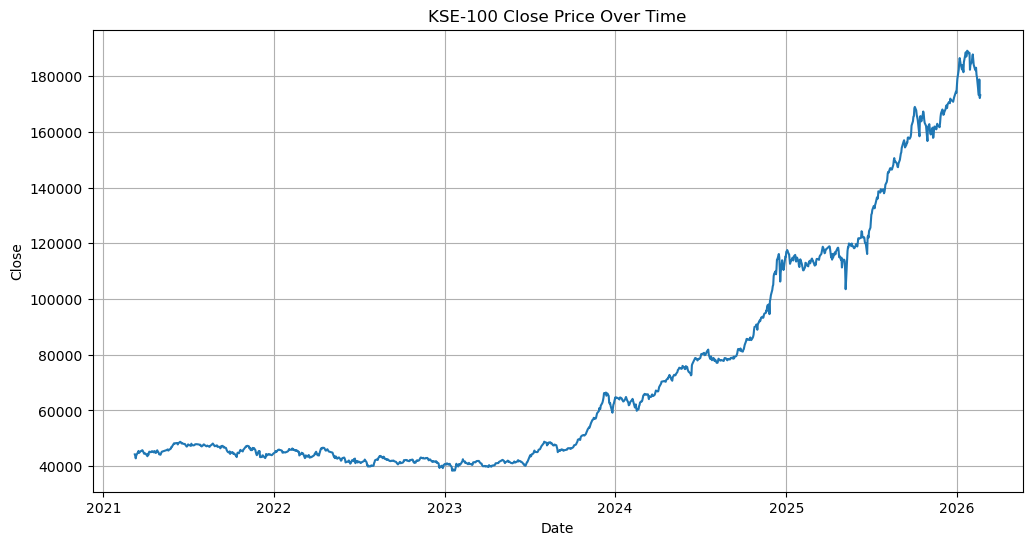

In [39]:
# Price trend 

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["Close"])
plt.title("KSE-100 Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

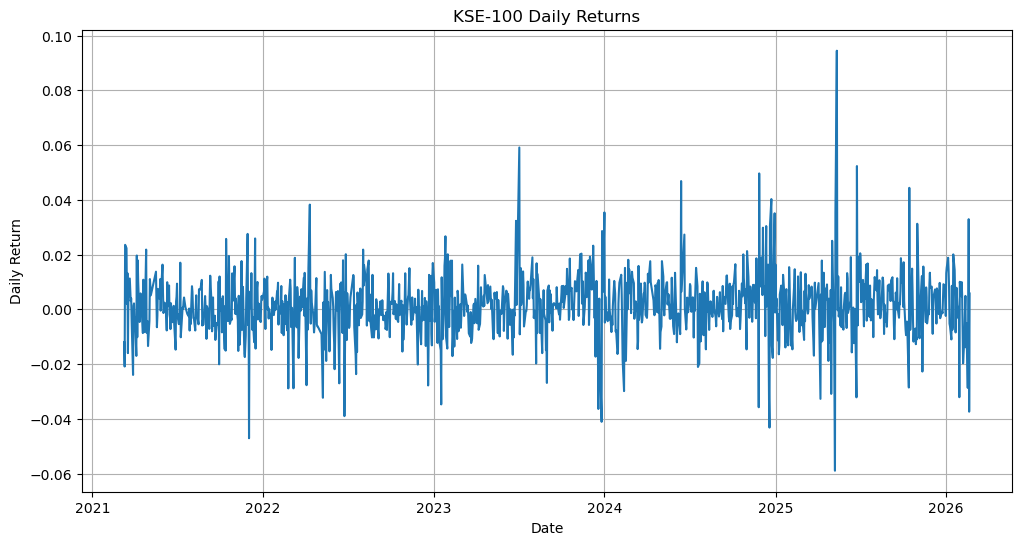

In [40]:
# Daily Returns 

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["daily_return"])
plt.title("KSE-100 Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [41]:
# ADF stationarity test on close

adf_result = adfuller(eda_df["Close"].dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

ADF Statistic: 2.6549147623117264
p-value: 0.9990833047086657
Critical Values:
  1%: -3.4357038129673962
  5%: -2.8639042041471887
  10%: -2.5680287376916997


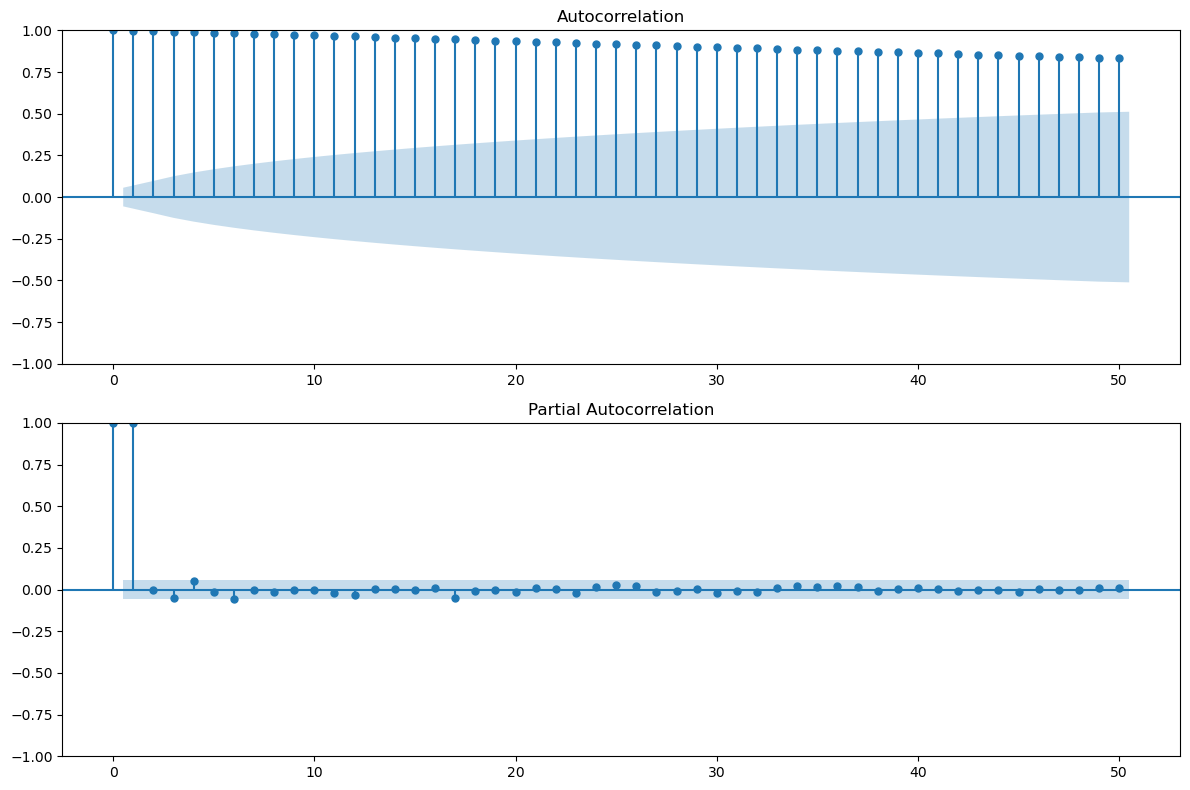

In [42]:
# ACF / PACF on close

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(eda_df["Close"].dropna(), lags=50, ax=axes[0])
plot_pacf(eda_df["Close"].dropna(), lags=50, ax=axes[1])
plt.tight_layout()
plt.show()

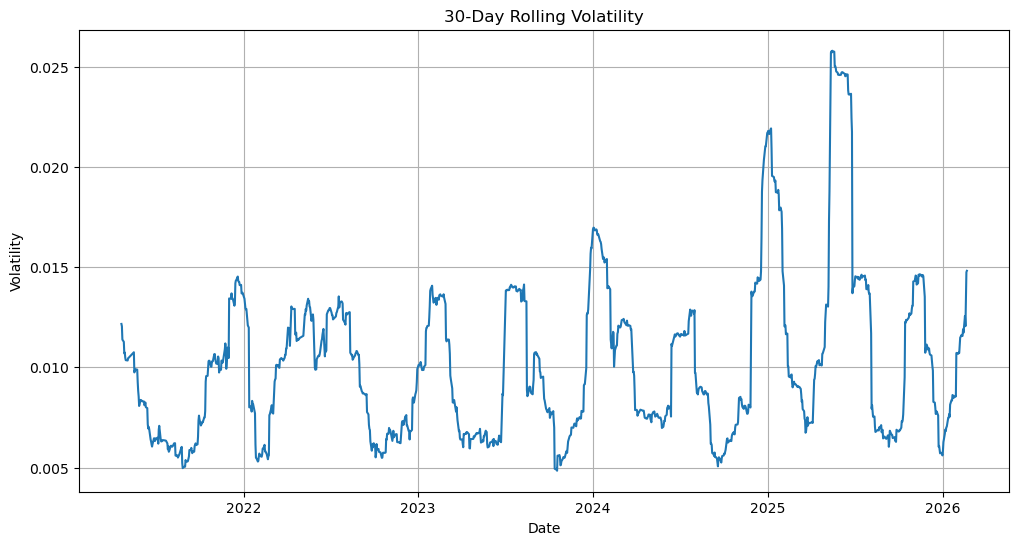

In [43]:
# 30-day rolling volatility

eda_df["Volatility_30d"] = eda_df["daily_return"].rolling(30).std()

plt.figure(figsize=(12, 6))
plt.plot(eda_df["Date"], eda_df["Volatility_30d"])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

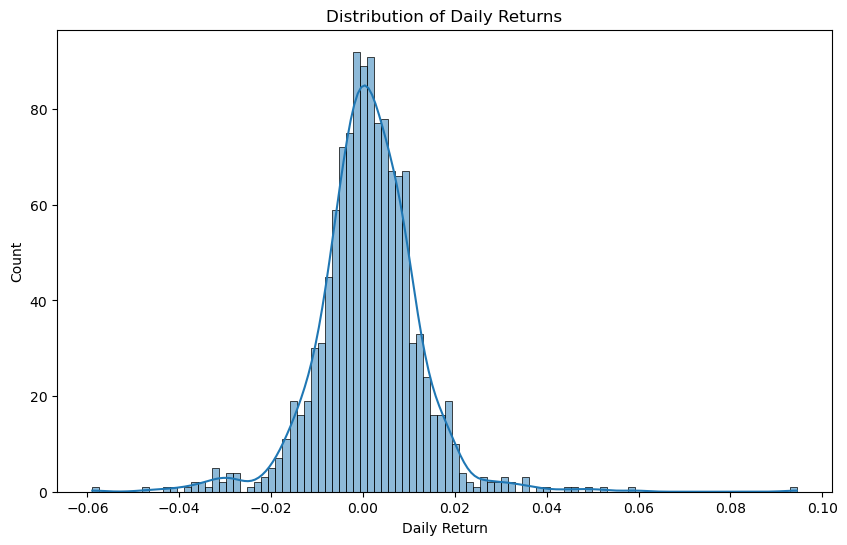

In [44]:
# Distribution of daily returns

plt.figure(figsize=(10, 6))
sns.histplot(eda_df["daily_return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

In [45]:
# Missing business days check

all_business_days = pd.bdate_range(start=eda_df["Date"].min(), end=eda_df["Date"].max())
missing_days = all_business_days.difference(eda_df["Date"])
print("Number of missing business days:", len(missing_days))

Number of missing business days: 67


In [46]:
# # Correlation snapshot with selected raw variables

# corr_df = model_df[candidate_features + ["target_next_log_return"]].copy()

# # Correlation with target
# target_corr = (
#     corr_df.corr()["target_next_log_return"]
#     .drop("target_next_log_return")
#     .sort_values(key=lambda x: x.abs(), ascending=False)
# )

# print("Correlation with target_next_log_return:")
# display(target_corr.to_frame("corr_with_target_next_log_return"))

# # Full correlation matrix for all features + target
# plt.figure(figsize=(22, 18))
# sns.heatmap(
#     corr_df.corr(),
#     cmap="coolwarm",
#     center=0,
#     square=False
# )
# plt.title("Correlation Matrix: Final Modeling Features and target_next_log_return")
# plt.show()

Volume skewness: 1.6636045266933002


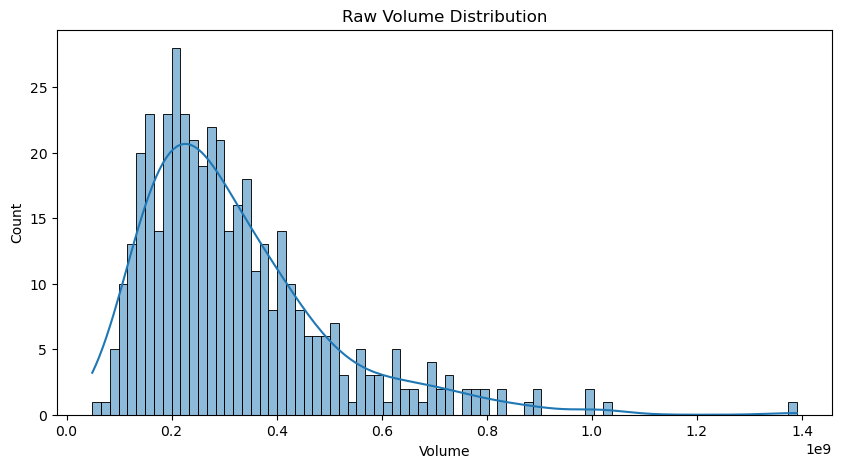

Normalized volume created using log1p because skewness > 1.


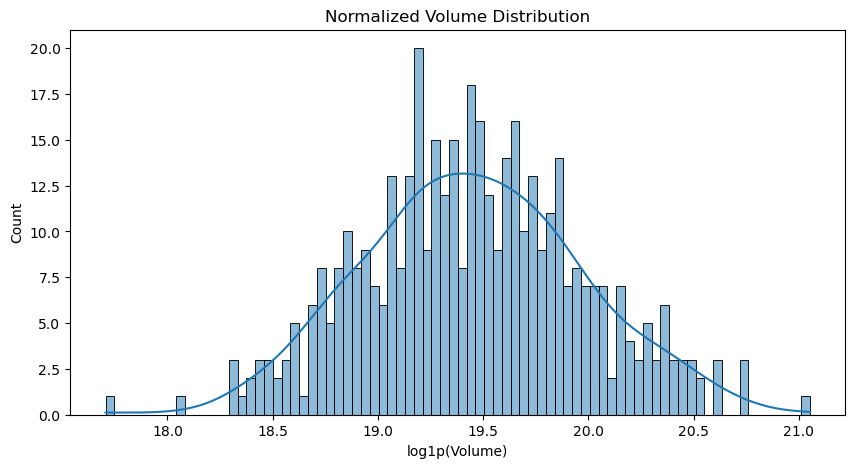

,Date,Volume,normalized_volume
0,2021-03-09,NaN,NaN
1,2021-03-10,NaN,NaN
2,2021-03-11,NaN,NaN
3,2021-03-12,NaN,NaN
4,2021-03-15,NaN,NaN


In [47]:
# Volume distribution and normalized volume decision

volume_skew = eda_df["Volume"].dropna().skew()
print("Volume skewness:", volume_skew)

plt.figure(figsize=(10, 5))
sns.histplot(eda_df["Volume"].dropna(), bins=80, kde=True)
plt.title("Raw Volume Distribution")
plt.xlabel("Volume")
plt.show()

if volume_skew > 1:
    # Log-normalized volume created because raw volume is right-skewed
    eda_df["normalized_volume"] = np.log1p(eda_df["Volume"])
    print("Normalized volume created using log1p because skewness > 1.")

    plt.figure(figsize=(10, 5))
    sns.histplot(eda_df["normalized_volume"].dropna(), bins=80, kde=True)
    plt.title("Normalized Volume Distribution")
    plt.xlabel("log1p(Volume)")
    plt.show()
else:
    # Normalized volume left equal to original volume because skewness is not severe
    eda_df["normalized_volume"] = eda_df["Volume"]
    print("Normalized volume not needed; original volume retained.")

display(eda_df[["Date", "Volume", "normalized_volume"]].head())

#### Feature engineering and final modeling dataset creation

In [49]:
feature_df = post_eda_df.copy()

feature_df = post_eda_df.copy()

# Safety check: ensure no temporary monthly CPI merge key remains
if "cpi_month_key" in feature_df.columns:
    feature_df = feature_df.drop(columns=["cpi_month_key"])

# Volume-derived feature: normalized volume created only if raw volume is materially right-skewed
volume_skew = feature_df["Volume"].dropna().skew()
if volume_skew > 1:
    feature_df["normalized_volume"] = np.log1p(feature_df["Volume"])
else:
    feature_df["normalized_volume"] = feature_df["Volume"]

# Add technical, regime, liquidity, and drawdown features
feature_df = add_technical_features(feature_df)

# Mamba-style target variable
if "Log_Return" not in feature_df.columns:
    feature_df["Log_Return"] = np.log(feature_df["Close"] / feature_df["Close"].shift(1))

# Initial feature list before correlation/VIF filtering
model_features = [
    "Log_Return",
    "SPY_Log_Return",
    "EEM_Log_Return",
    "VEA_Close_Log_Return",
    "VIX_Change",
    "Days_Since_Last_Trade",
    "Is_Post_Holiday",
    "Is_IMF_Event",
    "IMF_3Day_Window",
    "USDPKR_Log_Return",
    "annual_gdp_growth",
    "cpi",
    "kibor_rate",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "EMA_10",
    "EMA_20",
    "EMA_50",
    "Golden_Cross",
    "EMA_crossover",
    "RSI_14",
    "RSI_OB",
    "RSI_OS",
    "MACD_Line",
    "MACD_Signal",
    "MACD_Hist",
    "ROC_5",
    "BB_Upper",
    "BB_Lower",
    "BB_Middle",
    "BB_Width",
    "BB_Pct",
    "True_Range",
    "ATR_14",
    "ATR_Pct",
    "HV_20",
    "Trend_Regime",
    "kibor_rate_ma_5",
    "kibor_rate_ma_20",
    "kibor_rate_change_5",
    "kibor_rate_change_20",
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "return_lag_10",
    "rolling_max_close_63",
    "drawdown_63",
    "max_drawdown_63",
    "days_since_high_63",
    "rolling_max_close_252",
    "drawdown_252",
    "max_drawdown_252",
    "days_since_high_252"
]

# Keep only features that actually exist and are numeric
selected_features = [
    col for col in model_features
    if col in feature_df.columns and pd.api.types.is_numeric_dtype(feature_df[col])
]

# Pre-filter forecasting dataframe
forecast_df = feature_df[["Date", "Close"] + selected_features].copy()
forecast_df = (
    forecast_df
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .dropna()
    .reset_index(drop=True)
)

target_col = "Log_Return"

print("forecast_df shape:", forecast_df.shape)
print("Initial number of selected features:", len(selected_features))
display(pd.DataFrame({"selected_feature": selected_features}))
display(forecast_df.head())

forecast_df shape: (665, 58)
Initial number of selected features: 56


,selected_feature
0,Log_Return
1,SPY_Log_Return
2,EEM_Log_Return
3,VEA_Close_Log_Return
4,VIX_Change
5,Days_Since_Last_Trade
6,Is_Post_Holiday
7,Is_IMF_Event
8,IMF_3Day_Window
9,USDPKR_Log_Return


,Date,Close,Log_Return,SPY_Log_Return,EEM_Log_Return,VEA_Close_Log_Return,VIX_Change,Days_Since_Last_Trade,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,USDPKR_Log_Return,annual_gdp_growth,cpi,kibor_rate,SMA_10,SMA_20,SMA_50,SMA_200,EMA_10,EMA_20,EMA_50,Golden_Cross,EMA_crossover,RSI_14,RSI_OB,RSI_OS,MACD_Line,MACD_Signal,MACD_Hist,ROC_5,BB_Upper,BB_Lower,BB_Middle,BB_Width,BB_Pct,True_Range,ATR_14,ATR_Pct,HV_20,Trend_Regime,kibor_rate_ma_5,kibor_rate_ma_20,kibor_rate_change_5,kibor_rate_change_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,rolling_max_close_63,drawdown_63,max_drawdown_63,days_since_high_63,rolling_max_close_252,drawdown_252,max_drawdown_252,days_since_high_252
0,2023-03-16,41694.09,-0.004307,-0.006274,-0.017290,0.015392,2.410000,1,0,0,0,0.006203,-0.414936,219.138547,21.15,41608.577,41195.9940,40741.6156,41449.91050,41574.141665,41347.591120,41076.586349,0.0,1.0,57.872700,0.0,0.0,267.979885,208.187716,59.792169,0.261028,42158.063563,40233.924437,41195.9940,0.046707,0.758867,479.53,405.249577,0.971959,9.678007,0.011153,21.142,20.3440,0.04,2.33,0.001378,-0.000966,0.001507,0.005479,0.006387,42466.59,-0.018191,-0.110244,25.0,46601.54,-0.105307,-0.177233,228.0
1,2023-03-17,41329.95,-0.008772,0.017393,0.015178,-0.011639,-3.150000,1,0,0,0,0.000000,-0.414936,219.138547,21.15,41607.872,41206.5610,40748.0642,41445.37070,41529.743180,41345.911013,41086.522178,0.0,1.0,51.413706,0.0,0.0,233.020342,213.154241,19.866100,-1.110019,42169.693768,40243.428232,41206.5610,0.046747,0.564056,538.07,422.958967,1.023372,10.248724,0.011252,21.148,20.4575,0.03,2.27,-0.004297,0.001378,-0.000966,0.005010,0.016378,42466.59,-0.026766,-0.110244,26.0,46601.54,-0.113121,-0.177233,229.0
2,2023-03-20,40918.45,-0.010006,-0.011762,-0.006097,0.011407,2.520000,3,1,0,0,-0.023866,-0.414936,219.138547,21.16,41556.284,41218.8015,40756.3380,41443.38855,41418.598966,41305.200440,41079.931112,0.0,1.0,45.265548,0.0,0.0,170.148673,204.553128,-34.404455,-2.241927,42159.375123,40278.227877,41218.8015,0.045638,0.340336,488.79,431.736438,1.055114,10.126695,0.011347,21.154,20.5685,0.03,2.22,-0.008734,-0.004297,0.001378,0.001507,0.002355,42466.59,-0.036455,-0.110244,27.0,46601.54,-0.121951,-0.177233,230.0
3,2023-03-21,40877.98,-0.000990,0.009570,0.003716,0.012880,-1.360001,1,0,0,0,0.014602,-0.414936,219.138547,21.18,41510.613,41215.2085,40757.8676,41439.89240,41320.304608,41264.512779,41072.011461,0.0,1.0,44.699418,0.0,0.0,115.722850,186.787072,-71.064222,-2.244214,42160.644610,40269.772390,41215.2085,0.045878,0.321655,293.38,413.288913,1.011031,9.839890,0.011221,21.160,20.6775,0.03,2.18,-0.009956,-0.008734,-0.004297,-0.000966,-0.002405,42466.59,-0.037408,-0.110244,28.0,46601.54,-0.122819,-0.177233,231.0
4,2023-03-22,40376.10,-0.012354,0.013045,0.008966,-0.003892,-2.770000,1,0,0,0,-0.000924,-0.414936,219.138547,21.21,41412.330,41175.6335,40750.2256,41433.93085,41148.631043,41179.902038,41044.720815,0.0,0.0,38.301793,0.0,0.0,31.726746,155.775007,-124.048261,-3.577252,42192.987935,40158.279065,41175.6335,0.049415,0.107053,644.01,444.051724,1.099789,10.528751,0.010439,21.170,20.7850,0.05,2.15,-0.000989,-0.009956,-0.008734,0.001378,0.000586,42466.59,-0.049227,-0.110244,29.0,46601.54,-0.133589,-0.177233,232.0


#### Correlation and multicollinearity testing, then feature selection

In [51]:
# model_df = feature_df.copy()

# # Keep rows where the forecasting target exists
# model_df = model_df.dropna(subset=["target_next_log_return"]).reset_index(drop=True)

# # Volume-derived features to exclude from the final model
# volume_derived_features = [
#     "normalized_volume",
#     "Volume_SMA_20",
#     "Vol_Ratio",
#     "Volume_Median_20",
#     "Volume_Regime",
#     "Liquidity_Stress"
# ]

# # Final modeling feature list
# model_features = [
#     "Log_Return",
#     "SPY_Log_Return",
#     "EEM_Log_Return",
#     "VEA_Close_Log_Return",
#     "VIX_Change",
#     "Days_Since_Last_Trade",
#     "Is_Post_Holiday",
#     "Is_IMF_Event",
#     "IMF_3Day_Window",
#     "USDPKR_Log_Return",
#     "annual_gdp_growth",
#     "cpi",
#     "kibor_rate",
#     "SMA_10",
#     "SMA_20",
#     "SMA_50",
#     "SMA_200",
#     "EMA_10",
#     "EMA_20",
#     "EMA_50",
#     "Golden_Cross",
#     "EMA_crossover",
#     "RSI_14",
#     "RSI_OB",
#     "RSI_OS",
#     "MACD_Line",
#     "MACD_Signal",
#     "MACD_Hist",
#     "ROC_5",
#     "BB_Upper",
#     "BB_Lower",
#     "BB_Middle",
#     "BB_Width",
#     "BB_Pct",
#     "True_Range",
#     "ATR_14",
#     "ATR_Pct",
#     "HV_20",
#     "Trend_Regime",
#     "kibor_rate_ma_5",
#     "kibor_rate_ma_20",
#     "kibor_rate_change_5",
#     "kibor_rate_change_20",
#     "return_lag_1",
#     "return_lag_2",
#     "return_lag_3",
#     "return_lag_5",
#     "return_lag_10",
#     "rolling_max_close_63",
#     "drawdown_63",
#     "max_drawdown_63",
#     "days_since_high_63",
#     "rolling_max_close_252",
#     "drawdown_252",
#     "max_drawdown_252",
#     "days_since_high_252"
# ]

# candidate_features = [
#     col for col in model_features
#     if col in model_df.columns
#     and pd.api.types.is_numeric_dtype(model_df[col])
#     and col not in volume_derived_features
# ]

# print("Number of candidate features:", len(candidate_features))
# display(pd.DataFrame({"candidate_feature": candidate_features}))

In [52]:
# # Correlation with target

In [53]:
# target_corr = (
#     model_df[candidate_features + ["target_next_close"]]
#     .corr()["target_next_close"]
#     .drop("target_next_close")
#     .sort_values(key=lambda x: x.abs(), ascending=False)
# )

# print("Top correlations with target_next_close:")
# display(target_corr.head(25).to_frame("corr_with_target"))

In [54]:
# High-correlation pair filtering

corr_input_df = forecast_df[selected_features].copy()

corr_matrix = corr_input_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
corr_threshold = 0.95

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]

        if pd.notna(corr_value) and corr_value > corr_threshold:
            high_corr_pairs.append({
                "feature_1": row,
                "feature_2": col,
                "abs_correlation": corr_value
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

if not high_corr_pairs_df.empty:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        "abs_correlation", ascending=False
    ).reset_index(drop=True)

high_corr_drop = (
    sorted(high_corr_pairs_df["feature_2"].unique().tolist())
    if not high_corr_pairs_df.empty else []
)

correlation_filtered_features = [
    col for col in selected_features if col not in high_corr_drop
]

print(f"Correlation threshold used: {corr_threshold}")
print("Number of high-correlation pairs found:", len(high_corr_pairs_df))
display(high_corr_pairs_df)

print("Features identified to be dropped from high-correlation pair filtering:")
display(pd.DataFrame({"high_corr_drop_feature": high_corr_drop}))

print("Remaining features after high-correlation filtering:", len(correlation_filtered_features))
display(pd.DataFrame({"correlation_filtered_feature": correlation_filtered_features}))

Correlation threshold used: 0.95
Number of high-correlation pairs found: 70


,feature_1,feature_2,abs_correlation
0,SMA_20,BB_Middle,1.000000
1,SMA_10,EMA_10,0.999927
2,SMA_20,EMA_20,0.999892
3,EMA_20,BB_Middle,0.999892
4,rolling_max_close_63,rolling_max_close_252,0.999762
...,...,...,...
65,SMA_200,EMA_10,0.990389
66,SMA_10,SMA_200,0.990074
67,SMA_200,rolling_max_close_63,0.989799
68,SMA_200,BB_Upper,0.988713


Features identified to be dropped from high-correlation pair filtering:


,high_corr_drop_feature
0,BB_Lower
1,BB_Middle
2,BB_Upper
3,EMA_10
4,EMA_20
5,EMA_50
6,MACD_Signal
7,SMA_20
8,SMA_200
9,SMA_50


Remaining features after high-correlation filtering: 42


,correlation_filtered_feature
0,Log_Return
1,SPY_Log_Return
2,EEM_Log_Return
3,VEA_Close_Log_Return
4,VIX_Change
5,Days_Since_Last_Trade
6,Is_Post_Holiday
7,Is_IMF_Event
8,IMF_3Day_Window
9,USDPKR_Log_Return


In [55]:
# VIF filtering

vif_threshold = 5.0

vif_input_features = correlation_filtered_features.copy()
vif_input_df = forecast_df[vif_input_features].dropna().copy()

print("Rows available for VIF calculation:", len(vif_input_df))

initial_vif_results = calculate_vif(vif_input_df, vif_input_features)

print("Initial VIF results:")
display(initial_vif_results)

final_selected_features = vif_input_features.copy()
vif_drop_features = []

while True:
    current_vif_df = calculate_vif(vif_input_df, final_selected_features)

    if current_vif_df.empty:
        break

    max_vif = current_vif_df["VIF"].max()

    if max_vif <= vif_threshold:
        final_vif_results = current_vif_df.copy()
        break

    drop_feature = current_vif_df.loc[current_vif_df["VIF"].idxmax(), "feature"]
    vif_drop_features.append(drop_feature)
    final_selected_features.remove(drop_feature)

if "final_vif_results" not in locals():
    final_vif_results = calculate_vif(vif_input_df, final_selected_features)

print(f"VIF threshold used: {vif_threshold}")

print("Features identified to be dropped from VIF filtering:")
display(pd.DataFrame({"vif_drop_feature": vif_drop_features}))

print("Final VIF results after filtering:")
display(final_vif_results)

print("Final selected features after correlation + VIF filtering:")
display(pd.DataFrame({"final_selected_feature": final_selected_features}))

Rows available for VIF calculation: 665
Initial VIF results:


,feature,VIF
0,cpi,1588.425346
1,RSI_14,756.103490
2,SMA_10,355.083072
3,kibor_rate,265.960970
4,ATR_Pct,222.331705
5,ATR_14,193.977344
6,max_drawdown_252,153.232728
7,Golden_Cross,127.983497
8,drawdown_63,73.899893
9,BB_Pct,68.643880


VIF threshold used: 5.0
Features identified to be dropped from VIF filtering:


,vif_drop_feature
0,cpi
1,RSI_14
2,ATR_Pct
3,max_drawdown_252
4,Golden_Cross
5,ATR_14
6,drawdown_63
7,BB_Pct
8,Days_Since_Last_Trade
9,BB_Width


Final VIF results after filtering:


,feature,VIF
0,SPY_Log_Return,4.056397
1,Trend_Regime,3.492200
2,True_Range,3.462670
3,annual_gdp_growth,3.397863
4,VIX_Change,3.307253
5,days_since_high_63,3.175330
6,RSI_OB,3.106022
7,days_since_high_252,2.437964
8,MACD_Hist,2.413732
9,kibor_rate_change_20,2.028734


Final selected features after correlation + VIF filtering:


,final_selected_feature
0,Log_Return
1,SPY_Log_Return
2,EEM_Log_Return
3,VEA_Close_Log_Return
4,VIX_Change
5,Is_Post_Holiday
6,Is_IMF_Event
7,IMF_3Day_Window
8,USDPKR_Log_Return
9,annual_gdp_growth


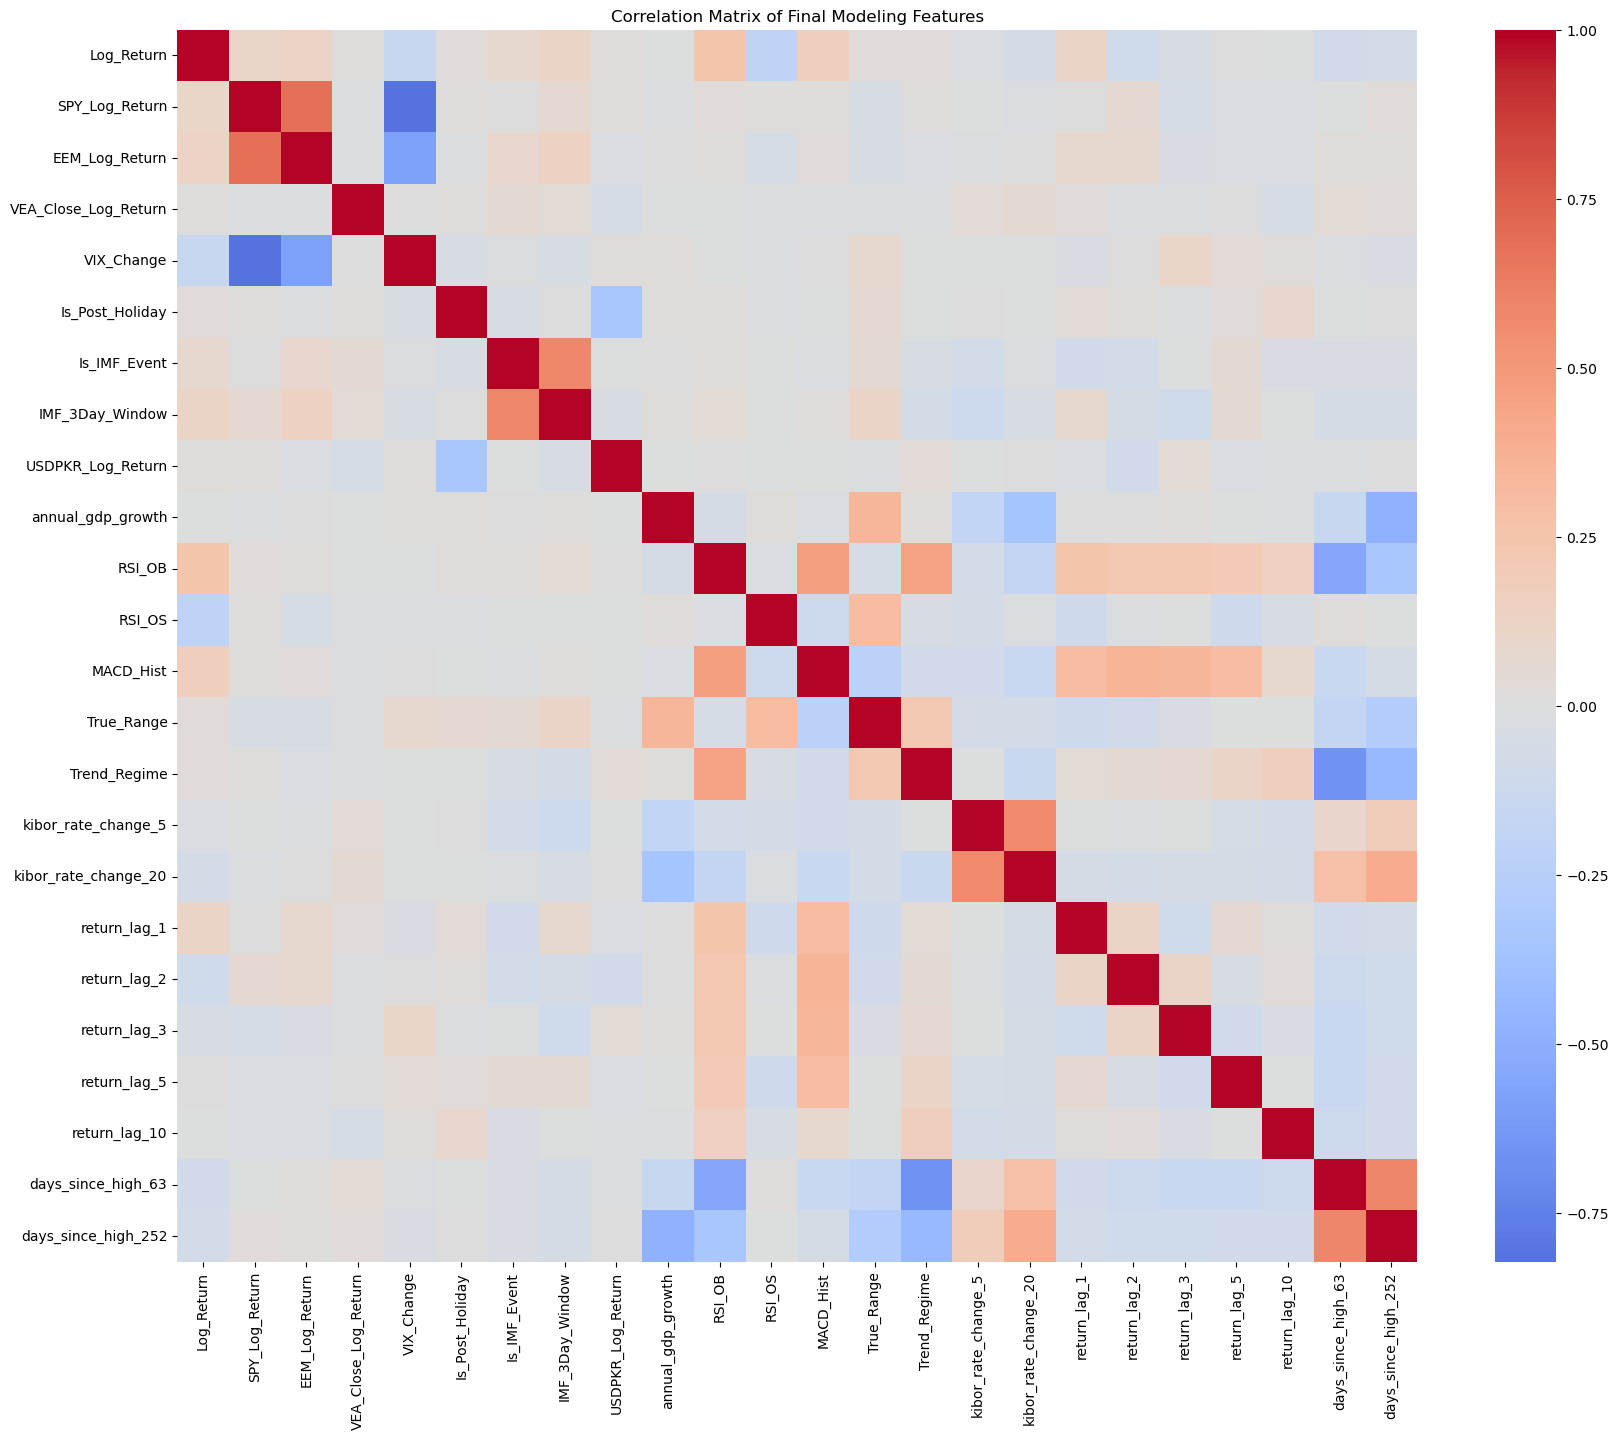

In [56]:
# Correlation matrix chart

corr_plot_df = forecast_df[final_selected_features].copy()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_plot_df.corr(),
    cmap="coolwarm",
    center=0,
    square=False
)
plt.title("Correlation Matrix of Final Modeling Features")
plt.show()

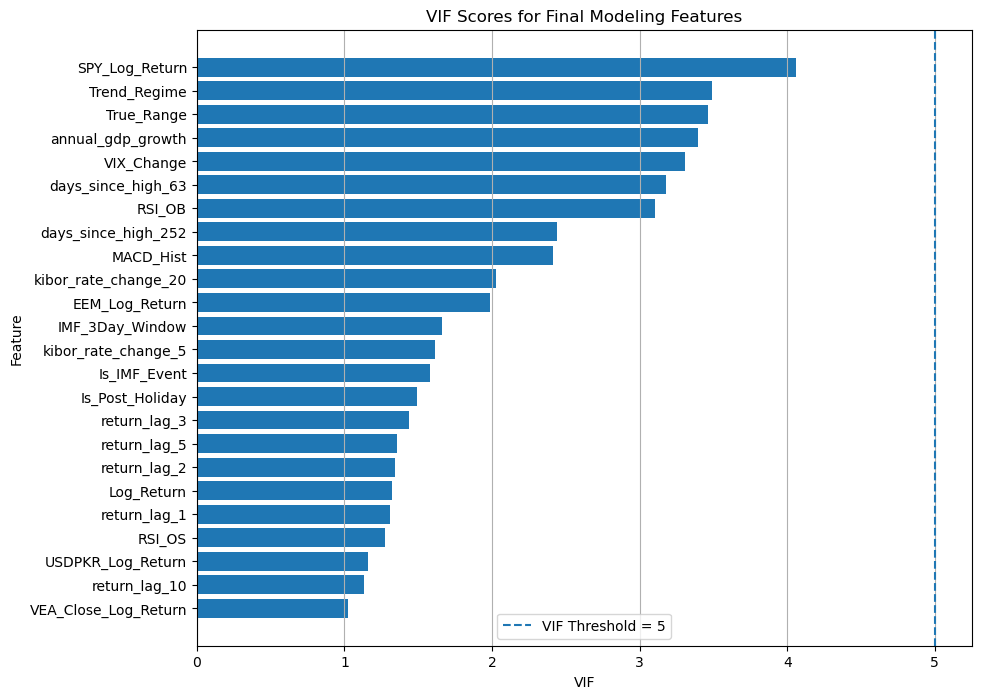

In [57]:
# VIF plot

vif_plot_df = final_vif_results.sort_values("VIF", ascending=True).copy()

plt.figure(figsize=(10, 8))
plt.barh(vif_plot_df["feature"], vif_plot_df["VIF"])
plt.axvline(x=5, linestyle="--", label="VIF Threshold = 5")
plt.title("VIF Scores for Final Modeling Features")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.legend()
plt.show()

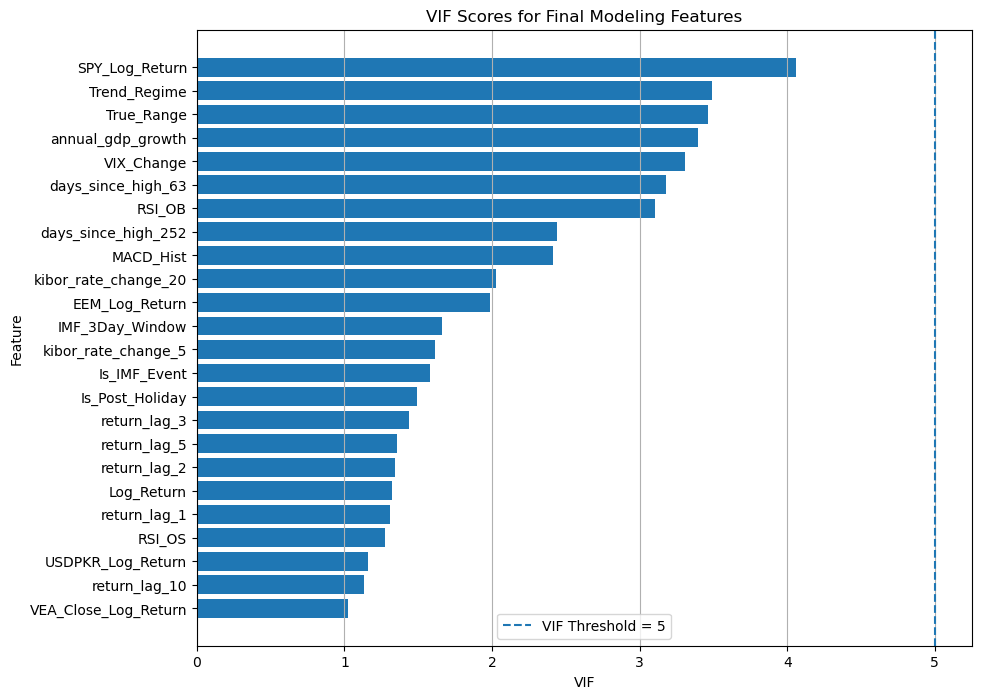

In [58]:
# VIF results 

vif_plot_df = final_vif_results.sort_values("VIF", ascending=True).copy()

plt.figure(figsize=(10, 8))
plt.barh(vif_plot_df["feature"], vif_plot_df["VIF"])
plt.axvline(x=5, linestyle="--", label="VIF Threshold = 5")
plt.title("VIF Scores for Final Modeling Features")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.legend()
plt.show()

In [59]:
# Summary of dropped features 

dropped_feature_summary = pd.DataFrame({
    "high_corr_drop_features": pd.Series(high_corr_drop),
    "vif_drop_features": pd.Series(vif_drop_features)
})

print("Summary of features identified for dropping:")
display(dropped_feature_summary)

all_dropped_features = sorted(set(high_corr_drop + vif_drop_features))

print("Combined list of all dropped features:")
display(pd.DataFrame({"dropped_feature": all_dropped_features}))

print("Final number of selected features:", len(final_selected_features))

Summary of features identified for dropping:


,high_corr_drop_features,vif_drop_features
0,BB_Lower,cpi
1,BB_Middle,RSI_14
2,BB_Upper,ATR_Pct
3,EMA_10,max_drawdown_252
4,EMA_20,Golden_Cross
5,EMA_50,ATR_14
6,MACD_Signal,drawdown_63
7,SMA_20,BB_Pct
8,SMA_200,Days_Since_Last_Trade
9,SMA_50,BB_Width


Combined list of all dropped features:


,dropped_feature
0,ATR_14
1,ATR_Pct
2,BB_Lower
3,BB_Middle
4,BB_Pct
5,BB_Upper
6,BB_Width
7,Days_Since_Last_Trade
8,EMA_10
9,EMA_20


Final number of selected features: 24


In [60]:
# Save filtered features dataset after high-correlation and VIF feature dropping

# # Save filtered features dataset after high-correlation and VIF feature dropping
# filtered_feature_df = forecast_df[["Date", "Close"] + final_selected_features].copy()

print("Filtered feature dataset shape:", filtered_feature_df.shape)
display(filtered_feature_df.head())

filtered_feature_df.to_csv("filtered_feature_df.csv", index=False)
filtered_feature_df.to_excel("filtered_feature_df.xlsx", index=False)

# print("Saved:")
# print("- filtered_feature_df.csv")
# print("- filtered_feature_df.xlsx")

# Final modeling dataframe for recursive forecasting models
model_forecast_df = filtered_feature_df.copy()

# Ensure Log_Return exists and is used as the target variable
if target_col not in model_forecast_df.columns:
    model_forecast_df = model_forecast_df.merge(
        forecast_df[["Date", target_col]],
        on="Date",
        how="left"
    )

model_forecast_df = (
    model_forecast_df
    .sort_values("Date")
    .drop_duplicates(subset=["Date"])
    .dropna()
    .reset_index(drop=True)
)

print("Model dataset shape:", model_forecast_df.shape)
print("Target column:", target_col)
print("Number of selected features:", len(final_selected_features))
display(pd.DataFrame({"selected_feature": final_selected_features}))
display(model_forecast_df.head())

Filtered feature dataset shape: (665, 26)


,Date,Close,Log_Return,SPY_Log_Return,EEM_Log_Return,VEA_Close_Log_Return,VIX_Change,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,USDPKR_Log_Return,annual_gdp_growth,RSI_OB,RSI_OS,MACD_Hist,True_Range,Trend_Regime,kibor_rate_change_5,kibor_rate_change_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,days_since_high_63,days_since_high_252
0,2023-03-16,41694.09,-0.004307,-0.006274,-0.017290,0.015392,2.410000,0,0,0,0.006203,-0.414936,0.0,0.0,59.792169,479.53,0.011153,0.04,2.33,0.001378,-0.000966,0.001507,0.005479,0.006387,25.0,228.0
1,2023-03-17,41329.95,-0.008772,0.017393,0.015178,-0.011639,-3.150000,0,0,0,0.000000,-0.414936,0.0,0.0,19.866100,538.07,0.011252,0.03,2.27,-0.004297,0.001378,-0.000966,0.005010,0.016378,26.0,229.0
2,2023-03-20,40918.45,-0.010006,-0.011762,-0.006097,0.011407,2.520000,1,0,0,-0.023866,-0.414936,0.0,0.0,-34.404455,488.79,0.011347,0.03,2.22,-0.008734,-0.004297,0.001378,0.001507,0.002355,27.0,230.0
3,2023-03-21,40877.98,-0.000990,0.009570,0.003716,0.012880,-1.360001,0,0,0,0.014602,-0.414936,0.0,0.0,-71.064222,293.38,0.011221,0.03,2.18,-0.009956,-0.008734,-0.004297,-0.000966,-0.002405,28.0,231.0
4,2023-03-22,40376.10,-0.012354,0.013045,0.008966,-0.003892,-2.770000,0,0,0,-0.000924,-0.414936,0.0,0.0,-124.048261,644.01,0.010439,0.05,2.15,-0.000989,-0.009956,-0.008734,0.001378,0.000586,29.0,232.0


Saved:
- filtered_feature_df.csv
- filtered_feature_df.xlsx
Model dataset shape: (665, 26)
Target column: Log_Return
Number of selected features: 24


,selected_feature
0,Log_Return
1,SPY_Log_Return
2,EEM_Log_Return
3,VEA_Close_Log_Return
4,VIX_Change
5,Is_Post_Holiday
6,Is_IMF_Event
7,IMF_3Day_Window
8,USDPKR_Log_Return
9,annual_gdp_growth


,Date,Close,Log_Return,SPY_Log_Return,EEM_Log_Return,VEA_Close_Log_Return,VIX_Change,Is_Post_Holiday,Is_IMF_Event,IMF_3Day_Window,USDPKR_Log_Return,annual_gdp_growth,RSI_OB,RSI_OS,MACD_Hist,True_Range,Trend_Regime,kibor_rate_change_5,kibor_rate_change_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,days_since_high_63,days_since_high_252
0,2023-03-16,41694.09,-0.004307,-0.006274,-0.017290,0.015392,2.410000,0,0,0,0.006203,-0.414936,0.0,0.0,59.792169,479.53,0.011153,0.04,2.33,0.001378,-0.000966,0.001507,0.005479,0.006387,25.0,228.0
1,2023-03-17,41329.95,-0.008772,0.017393,0.015178,-0.011639,-3.150000,0,0,0,0.000000,-0.414936,0.0,0.0,19.866100,538.07,0.011252,0.03,2.27,-0.004297,0.001378,-0.000966,0.005010,0.016378,26.0,229.0
2,2023-03-20,40918.45,-0.010006,-0.011762,-0.006097,0.011407,2.520000,1,0,0,-0.023866,-0.414936,0.0,0.0,-34.404455,488.79,0.011347,0.03,2.22,-0.008734,-0.004297,0.001378,0.001507,0.002355,27.0,230.0
3,2023-03-21,40877.98,-0.000990,0.009570,0.003716,0.012880,-1.360001,0,0,0,0.014602,-0.414936,0.0,0.0,-71.064222,293.38,0.011221,0.03,2.18,-0.009956,-0.008734,-0.004297,-0.000966,-0.002405,28.0,231.0
4,2023-03-22,40376.10,-0.012354,0.013045,0.008966,-0.003892,-2.770000,0,0,0,-0.000924,-0.414936,0.0,0.0,-124.048261,644.01,0.010439,0.05,2.15,-0.000989,-0.009956,-0.008734,0.001378,0.000586,29.0,232.0


#### Outlier Analysis

In [62]:
# outlier_summary = []

# for col in selected_features:
#     series = model_forecast_df[col].dropna()

#     if len(series) == 0:
#         outlier_summary.append({
#             "feature": col,
#             "q1": np.nan,
#             "q3": np.nan,
#             "iqr": np.nan,
#             "lower_bound": np.nan,
#             "upper_bound": np.nan,
#             "outlier_count": np.nan,
#             "outlier_pct": np.nan
#         })
#         continue

#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1

#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     outlier_mask = (series < lower_bound) | (series > upper_bound)
#     outlier_count = int(outlier_mask.sum())
#     outlier_pct = (outlier_count / len(series)) * 100

#     outlier_summary.append({
#         "feature": col,
#         "q1": q1,
#         "q3": q3,
#         "iqr": iqr,
#         "lower_bound": lower_bound,
#         "upper_bound": upper_bound,
#         "outlier_count": outlier_count,
#         "outlier_pct": outlier_pct
#     })

# outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)

# print("Outlier summary using IQR rule:")
# display(outlier_summary_df)

In [63]:
# # Outlier analysis

# outlier_summary = []

# for col in selected_features:
#     series = model_forecast_df[col].dropna()

#     if len(series) == 0:
#         outlier_summary.append({
#             "feature": col,
#             "q1": np.nan,
#             "q3": np.nan,
#             "iqr": np.nan,
#             "lower_bound": np.nan,
#             "upper_bound": np.nan,
#             "outlier_count": np.nan,
#             "outlier_pct": np.nan
#         })
#         continue

#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1

#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     outlier_mask = (series < lower_bound) | (series > upper_bound)
#     outlier_count = int(outlier_mask.sum())
#     outlier_pct = (outlier_count / len(series)) * 100

#     outlier_summary.append({
#         "feature": col,
#         "q1": q1,
#         "q3": q3,
#         "iqr": iqr,
#         "lower_bound": lower_bound,
#         "upper_bound": upper_bound,
#         "outlier_count": outlier_count,
#         "outlier_pct": outlier_pct
#     })

# outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)

# print("Outlier summary using IQR rule:")
# display(outlier_summary_df)

In [64]:
# for col in selected_features:
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     sns.histplot(model_forecast_df[col].dropna(), bins=40, kde=True, ax=axes[0])
#     axes[0].set_title(f"Distribution of {col}")
#     axes[0].set_xlabel(col)
#     axes[0].set_ylabel("Frequency")

#     sns.boxplot(x=model_df[col], ax=axes[1])
#     axes[1].set_title(f"Boxplot of {col}")
#     axes[1].set_xlabel(col)

#     plt.tight_layout()
#     plt.show()

### Train / validation / evaluation split and model training

In [66]:
# # Chronological split:
# # train = first 70%
# # validation = next 20%
# # evaluation = final 10%
# train_df, val_df, test_df = chronological_split(model_df, 0.70, 0.20, 0.10)

# print("Train shape:", train_df.shape)
# print("Validation shape:", val_df.shape)
# print("Test shape:", test_df.shape)

# X_train = train_df[selected_features]
# X_val = val_df[selected_features]
# X_test = test_df[selected_features]

# y_train = train_df["target_next_log_return"]
# y_val = val_df["target_next_log_return"]
# y_test = test_df["target_next_log_return"]

# print("Forecast target used for all models: target_next_log_return")
# print("Number of final modeling features:", len(selected_features))
# display(pd.DataFrame({"final_model_feature": selected_features}))

### Modelling

In [ ]:
# RUN XGBOOST, SARIMAX, AND LSTM USING:
# - Log_Return target
# - lookback window = 60
# - recursive multi-step forecasting
# - rolling time-series evaluation
# - mean engine + variance engine
# =========================================================

xgb_fold_metrics, xgb_avg_metrics, xgb_plot_data = run_rolling_cv_for_model(
    model_forecast_df,
    model_name="XGBoost",
    feature_cols=final_selected_features,
    target_col=target_col,
    seq_length=SEQ_LENGTH,
    horizon_size=HORIZON_SIZE,
    n_splits=N_SPLITS,
    mc_samples=MC_SAMPLES
)

sarimax_fold_metrics, sarimax_avg_metrics, sarimax_plot_data = run_rolling_cv_for_model(
    model_forecast_df,
    model_name="SARIMAX",
    feature_cols=final_selected_features,
    target_col=target_col,
    seq_length=SEQ_LENGTH,
    horizon_size=HORIZON_SIZE,
    n_splits=N_SPLITS,
    mc_samples=MC_SAMPLES
)

# lstm_fold_metrics, lstm_avg_metrics, lstm_plot_data = run_rolling_cv_for_model(
#     model_forecast_df,
#     model_name="LSTM",
#     feature_cols=final_selected_features,
#     target_col=target_col,
#     seq_length=SEQ_LENGTH,
#     horizon_size=HORIZON_SIZE,
#     n_splits=N_SPLITS,
#     mc_samples=MC_SAMPLES
# )

comparison_df = pd.concat(
    [xgb_avg_metrics, sarimax_avg_metrics, lstm_avg_metrics],
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "SMAPE",
        "Directional_Accuracy",
        "Coverage",
        "Mean_Interval_Width",
        "Winkler_Score"
    ]
]

display(comparison_df)

C:\Users\sami-\anaconda3\envs\ts_project\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sami-\anaconda3\envs\ts_project\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\sami-\anaconda3\envs\ts_project\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### 1) XGBoost Model 

In [ ]:
# xgb_imputer = SimpleImputer(strategy="median")

# X_train_xgb = xgb_imputer.fit_transform(X_train)
# X_val_xgb = xgb_imputer.transform(X_val)
# X_test_xgb = xgb_imputer.transform(X_test)

# xgb_model = XGBRegressor(
#     n_estimators=300,
#     max_depth=5,
#     learning_rate=0.03,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     random_state=42
# )

# xgb_model.fit(X_train_xgb, y_train)

# xgb_val_pred = xgb_model.predict(X_val_xgb)
# xgb_test_pred = xgb_model.predict(X_test_xgb)

# xgb_val_metrics = regression_metrics(y_val, xgb_val_pred)
# xgb_test_metrics = regression_metrics(y_test, xgb_test_pred)

# xgb_metrics_df = pd.DataFrame([xgb_val_metrics, xgb_test_metrics], index=["Validation", "Test"])
# display(xgb_metrics_df)

# xgb_val_results = val_df[["Date", "target_next_log_return"]].copy()
# xgb_val_results["xgb_predicted_log_return"] = xgb_val_pred

# xgb_test_results = test_df[["Date", "target_next_log_return"]].copy()
# xgb_test_results["xgb_predicted_log_return"] = xgb_test_pred

In [ ]:
# Plot metrics

metrics_to_plot = [
    "MAE",
    "RMSE",
    "MAPE",
    "SMAPE",
    "Directional_Accuracy",
    "Coverage",
    "Mean_Interval_Width",
    "Winkler_Score"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    plt.bar(comparison_df["Model"], comparison_df[metric])
    plt.title(f"{metric} Comparison Across Models")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(True, axis="y")
    plt.show()

In [ ]:
# PLOT LAST-FOLD FORECASTS WITH HYBRID GARCH BANDS

def plot_last_fold(plot_data, model_name):
    plt.figure(figsize=(14, 7))

    train_dates = plot_data["train_dates"].iloc[-100:]
    train_prices = plot_data["train_prices"][-100:]
    test_dates = plot_data["test_dates"]

    plt.plot(train_dates, train_prices, label="Actual (Train History)", color="black", linewidth=2)
    plt.plot(test_dates, plot_data["actual_prices"], label="Actual (Test)", color="blue", linewidth=2)
    plt.plot(test_dates, plot_data["predicted_prices"], label=f"{model_name} Mean Prediction", linestyle="--", color="red")
    plt.fill_between(
        test_dates,
        plot_data["lower_prices"],
        plot_data["upper_prices"],
        color="purple",
        alpha=0.2,
        label="Hybrid GARCH Interval"
    )

    plt.title(f"KSE100 Forecast: {model_name} Mean Engine + Variance Engine")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_last_fold(xgb_plot_data, "XGBoost")
plot_last_fold(sarimax_plot_data, "SARIMAX")
plot_last_fold(lstm_plot_data, "LSTM")

In [ ]:
# save metrics 

xgb_fold_metrics.to_csv("xgboost_fold_metrics.csv", index=False)
sarimax_fold_metrics.to_csv("sarimax_fold_metrics.csv", index=False)
lstm_fold_metrics.to_csv("lstm_fold_metrics.csv", index=False)

print("Saved:")
print("- xgboost_fold_metrics.csv")
print("- sarimax_fold_metrics.csv")
print("- lstm_fold_metrics.csv")

#### 2) SARIMAX Model

In [ ]:
# sarimax_exog_features = selected_features.copy()

# sarimax_imputer = SimpleImputer(strategy="median")

# sarimax_train_exog = pd.DataFrame(
#     sarimax_imputer.fit_transform(train_df[sarimax_exog_features]),
#     columns=sarimax_exog_features,
#     index=train_df.index
# # )

# sarimax_val_exog = pd.DataFrame(
#     sarimax_imputer.transform(val_df[sarimax_exog_features]),
#     columns=sarimax_exog_features,
#     index=val_df.index
# )

# sarimax_test_exog = pd.DataFrame(
#     sarimax_imputer.transform(test_df[sarimax_exog_features]),
#     columns=sarimax_exog_features,
#     index=test_df.index
# )

# sarimax_train_y = train_df["target_next_log_return"]
# sarimax_val_y = val_df["target_next_log_return"]
# sarimax_test_y = test_df["target_next_log_return"]

# sarimax_model = SARIMAX(
#     endog=sarimax_train_y,
#     exog=sarimax_train_exog,
#     order=(1, 0, 1),
#     seasonal_order=(0, 0, 0, 0),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# sarimax_fit = sarimax_model.fit(disp=False)

# sarimax_val_pred = sarimax_fit.get_forecast(
#     steps=len(sarimax_val_y),
#     exog=sarimax_val_exog
# ).predicted_mean

# sarimax_train_val_y = pd.concat([sarimax_train_y, sarimax_val_y], axis=0)
# sarimax_train_val_exog = pd.concat([sarimax_train_exog, sarimax_val_exog], axis=0)

# sarimax_model_refit = SARIMAX(
#     endog=sarimax_train_val_y,
#     exog=sarimax_train_val_exog,
#     order=(1, 0, 1),
#     seasonal_order=(0, 0, 0, 0),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# sarimax_fit_refit = sarimax_model_refit.fit(disp=False)

# sarimax_test_pred = sarimax_fit_refit.get_forecast(
#     steps=len(sarimax_test_y),
#     exog=sarimax_test_exog
# ).predicted_mean

# sarimax_val_metrics = regression_metrics(sarimax_val_y, sarimax_val_pred)
# sarimax_test_metrics = regression_metrics(sarimax_test_y, sarimax_test_pred)

# sarimax_metrics_df = pd.DataFrame([sarimax_val_metrics, sarimax_test_metrics], index=["Validation", "Test"])
# display(sarimax_metrics_df)

# sarimax_val_results = val_df[["Date", "target_next_log_return"]].copy()
# sarimax_val_results["sarimax_predicted_log_return"] = sarimax_val_pred.values

# sarimax_test_results = test_df[["Date", "target_next_log_return"]].copy()
# sarimax_test_results["sarimax_predicted_log_return"] = sarimax_test_pred.values

#### 3) LSTM MODEL

In [ ]:
# lstm_features = selected_features.copy()

# train_medians = X_train.median()

# X_train_lstm_df = X_train.fillna(train_medians)
# X_val_lstm_df = X_val.fillna(train_medians)
# X_test_lstm_df = X_test.fillna(train_medians)

# x_scaler = StandardScaler()
# X_train_scaled = x_scaler.fit_transform(X_train_lstm_df)
# X_val_scaled = x_scaler.transform(X_val_lstm_df)
# X_test_scaled = x_scaler.transform(X_test_lstm_df)

# y_scaler = StandardScaler()
# y_train_scaled = y_scaler.fit_transform(y_train.to_frame()).flatten()
# y_val_scaled = y_scaler.transform(y_val.to_frame()).flatten()
# y_test_scaled = y_scaler.transform(y_test.to_frame()).flatten()

# lookback = 20

# def create_lstm_sequences(X, y, dates, lookback=20):
#     X_seq, y_seq, date_seq = [], [], []

#     for i in range(lookback, len(X)):
#         X_seq.append(X[i - lookback:i])
#         y_seq.append(y[i])
#         date_seq.append(dates.iloc[i])

#     return np.array(X_seq), np.array(y_seq), pd.Series(date_seq).reset_index(drop=True)

# X_train_seq, y_train_seq, train_seq_dates = create_lstm_sequences(
#     X_train_scaled, y_train_scaled, train_df["Date"], lookback=lookback
# )

# X_val_seq, y_val_seq, val_seq_dates = create_lstm_sequences(
#     X_val_scaled, y_val_scaled, val_df["Date"], lookback=lookback
# )

# X_test_seq, y_test_seq, test_seq_dates = create_lstm_sequences(
#     X_test_scaled, y_test_scaled, test_df["Date"], lookback=lookback
# )

In [ ]:
# lstm_model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
#     Dropout(0.2),
#     LSTM(32, return_sequences=False),
#     Dropout(0.2),
#     Dense(16, activation="relu"),
#     Dense(1)
# ])

# lstm_model.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=["mae"]
# )

# early_stopping = EarlyStopping(
#     monitor="val_loss",
#     patience=10,
#     restore_best_weights=True
# )

# lstm_history = lstm_model.fit(
#     X_train_seq,
#     y_train_seq,
#     validation_data=(X_val_seq, y_val_seq),
#     epochs=100,
#     batch_size=32,
#     callbacks=[early_stopping],
#     verbose=1
# )

# lstm_val_pred_scaled = lstm_model.predict(X_val_seq).flatten()
# lstm_test_pred_scaled = lstm_model.predict(X_test_seq).flatten()

# lstm_val_pred = y_scaler.inverse_transform(lstm_val_pred_scaled.reshape(-1, 1)).flatten()
# lstm_test_pred = y_scaler.inverse_transform(lstm_test_pred_scaled.reshape(-1, 1)).flatten()

# lstm_val_actual = y_scaler.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
# lstm_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# lstm_val_metrics = regression_metrics(lstm_val_actual, lstm_val_pred)
# lstm_test_metrics = regression_metrics(lstm_test_actual, lstm_test_pred)

# lstm_metrics_df = pd.DataFrame([lstm_val_metrics, lstm_test_metrics], index=["Validation", "Test"])
# display(lstm_metrics_df)

# lstm_val_results = pd.DataFrame({
#     "Date": val_seq_dates,
#     "target_next_log_return": lstm_val_actual,
#     "lstm_predicted_log_return": lstm_val_pred
# })

# lstm_test_results = pd.DataFrame({
#     "Date": test_seq_dates,
#     "target_next_log_return": lstm_test_actual,
#     "lstm_predicted_log_return": lstm_test_pred
# })

#### Model Evaluation Metrics

In [ ]:
# comparison_df = pd.DataFrame({
#     "Model": ["XGBoost", "SARIMAX", "LSTM"],
#     "Validation_MAE": [
#         xgb_val_metrics["MAE"],
#         sarimax_val_metrics["MAE"],
#         lstm_val_metrics["MAE"]
#     ],
#     "Validation_RMSE": [
#         xgb_val_metrics["RMSE"],
#         sarimax_val_metrics["RMSE"],
#         lstm_val_metrics["RMSE"]
#     ],
#     "Validation_MAPE": [
#         xgb_val_metrics["MAPE"],
#         sarimax_val_metrics["MAPE"],
#         lstm_val_metrics["MAPE"]
#     ],
#     "Validation_R2": [
#         xgb_val_metrics["R2"],
#         sarimax_val_metrics["R2"],
#         lstm_val_metrics["R2"]
#     ],
#     "Test_MAE": [
#         xgb_test_metrics["MAE"],
#         sarimax_test_metrics["MAE"],
#         lstm_test_metrics["MAE"]
#     ],
#     "Test_RMSE": [
#         xgb_test_metrics["RMSE"],
#         sarimax_test_metrics["RMSE"],
#         lstm_test_metrics["RMSE"]
#     ],
#     "Test_MAPE": [
#         xgb_test_metrics["MAPE"],
#         sarimax_test_metrics["MAPE"],
#         lstm_test_metrics["MAPE"]
#     ],
#     "Test_R2": [
#         xgb_test_metrics["R2"],
#         sarimax_test_metrics["R2"],
#         lstm_test_metrics["R2"]
#     ]
# })

# display(comparison_df)

In [ ]:
# # Plot 

# metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2"]

# for metric in metrics_to_plot:
#     plot_df = pd.DataFrame({
#         "Model": ["XGBoost", "SARIMAX", "LSTM"],
#         "Validation": [
#             xgb_val_metrics[metric],
#             sarimax_val_metrics[metric],
#             lstm_val_metrics[metric]
#         ],
#         "Test": [
#             xgb_test_metrics[metric],
#             sarimax_test_metrics[metric],
#             lstm_test_metrics[metric]
#         ]
#     })

#     plot_long = plot_df.melt(id_vars="Model", var_name="Split", value_name="Value")

#     plt.figure(figsize=(10, 5))
#     sns.barplot(data=plot_long, x="Model", y="Value", hue="Split")
#     plt.title(f"{metric} Comparison Across Models")
#     plt.xlabel("Model")
#     plt.ylabel(metric)
#     plt.grid(True, axis="y")
#     plt.show()

In [ ]:
# Plot actual vs predicted 

plt.figure(figsize=(14, 6))
plt.plot(xgb_val_results["Date"], xgb_val_results["target_next_log_return"], label="Actual")
plt.plot(xgb_val_results["Date"], xgb_val_results["xgb_predicted_log_return"], label="XGBoost Predicted")
plt.title("XGBoost: Validation Actual vs Predicted target_next_log_return")
plt.xlabel("Date")
plt.ylabel("target_next_log_return")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(sarimax_val_results["Date"], sarimax_val_results["target_next_log_return"], label="Actual")
plt.plot(sarimax_val_results["Date"], sarimax_val_results["sarimax_predicted_log_return"], label="SARIMAX Predicted")
plt.title("SARIMAX: Validation Actual vs Predicted target_next_log_return")
plt.xlabel("Date")
plt.ylabel("target_next_log_return")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(lstm_val_results["Date"], lstm_val_results["target_next_log_return"], label="Actual")
plt.plot(lstm_val_results["Date"], lstm_val_results["lstm_predicted_log_return"], label="LSTM Predicted")
plt.title("LSTM: Validation Actual vs Predicted target_next_log_return")
plt.xlabel("Date")
plt.ylabel("target_next_log_return")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# # HistGradientBoosting is used here for nonlinear relationships and mixed feature scales
# # Median imputation handles missing values conservatively without using future data
# model = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("regressor", HistGradientBoostingRegressor(
#         learning_rate=0.03,
#         max_depth=5,
#         max_iter=300,
#         min_samples_leaf=20,
#         random_state=RANDOM_STATE
#     ))
# ])

# model.fit(X_train, y_train)

In [ ]:
# # Convert predicted next-day log return into predicted next-day price
# val_pred_log_return = model.predict(X_val)
# test_pred_log_return = model.predict(X_test)

# val_pred_price = val_df["Close"].values * np.exp(val_pred_log_return)
# test_pred_price = test_df["Close"].values * np.exp(test_pred_log_return)

# val_metrics = regression_metrics(y_val_actual_price, val_pred_price)
# test_metrics = regression_metrics(y_test_actual_price, test_pred_price)

# metrics_df = pd.DataFrame([val_metrics, test_metrics], index=["Validation", "Evaluation"])
# display(metrics_df)


In [ ]:
# # Save predictions back into split dataframes
# val_results = val_df[["Date", "Close", "target_next_close"]].copy()
# val_results["predicted_next_close"] = val_pred_price

# test_results = test_df[["Date", "Close", "target_next_close"]].copy()
# test_results["predicted_next_close"] = test_pred_price

# display(val_results.head())
# display(test_results.head())

### Plot model error metrics and actual vs predicted prices

In [ ]:
# # Metrics bar chart

# plot_metrics_df = metrics_df.reset_index().rename(columns={"index": "Split"})
# plot_metrics_long = plot_metrics_df.melt(id_vars="Split", var_name="Metric", value_name="Value")

# plt.figure(figsize=(12, 6))
# sns.barplot(data=plot_metrics_long, x="Metric", y="Value", hue="Split")
# plt.title("Model Error Metrics by Split")
# plt.xlabel("Metric")
# plt.ylabel("Value")
# plt.grid(True, axis="y")
# plt.show()

In [ ]:
# # Validation actual vs predicted

# plt.figure(figsize=(14, 6))
# plt.plot(val_results["Date"], val_results["target_next_close"], label="Actual Next Close")
# plt.plot(val_results["Date"], val_results["predicted_next_close"], label="Predicted Next Close")
# plt.title("Validation Period: Actual vs Predicted Next-Day Close")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # Evaluation actual vs predicted

# plt.figure(figsize=(14, 6))
# plt.plot(test_results["Date"], test_results["target_next_close"], label="Actual Next Close")
# plt.plot(test_results["Date"], test_results["predicted_next_close"], label="Predicted Next Close")
# plt.title("Evaluation Period: Actual vs Predicted Next-Day Close")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend()
# plt.grid(True)
# plt.show()

### Create trade signals and run backtest on the validation data

In [ ]:
# backtest_df = val_results.copy()

# # Predicted next-day return from today's close
# backtest_df["predicted_next_return"] = backtest_df["predicted_next_close"] / backtest_df["Close"] - 1

# # Trade signal based on predicted next-day price relative to today's close
# backtest_df["trade_signal"] = backtest_df.apply(
#     lambda row: generate_trade_signal(
#         predicted_next_close=row["predicted_next_close"],
#         current_close=row["Close"],
#         buy_threshold=BUY_THRESHOLD,
#         sell_threshold=SELL_THRESHOLD
#     ),
#     axis=1
# )

# display(backtest_df.head())

# print("Trade signal counts:")
# display(backtest_df["trade_signal"].value_counts())

# # Run portfolio backtest
# backtest_results = run_backtest(backtest_df, initial_capital=INITIAL_CAPITAL)

# # Final portfolio and benchmark values
# final_portfolio_value = backtest_results["portfolio_value"].iloc[-1]
# final_index_value = backtest_results["benchmark_index_value"].iloc[-1]

# print(f"Final benchmark index value over validation period: ${final_index_value:,.2f}")
# print(f"Final portfolio value over validation period: ${final_portfolio_value:,.2f}")

# display(backtest_results.head())
# display(backtest_results.tail())

In [ ]:
# # Plot backtest portfolio value vs benchmark and export outputs
# # Portfolio value vs benchmark

# plt.figure(figsize=(14, 6))
# plt.plot(backtest_results["Date"], backtest_results["portfolio_value"], label="Strategy Portfolio Value")
# plt.plot(backtest_results["Date"], backtest_results["benchmark_index_value"], label="Benchmark Index Value")
# plt.title("Backtest on Validation Period: Portfolio vs Benchmark")
# plt.xlabel("Date")
# plt.ylabel("Portfolio Value")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # Plot trade signals on price chart

# plt.figure(figsize=(14, 6))
# plt.plot(backtest_results["Date"], backtest_results["Close"], label="Close Price")

# buy_points = backtest_results[backtest_results["trade_signal"] == "BUY"]
# sell_points = backtest_results[backtest_results["trade_signal"] == "SELL"]

# plt.scatter(buy_points["Date"], buy_points["Close"], marker="^", s=100, label="BUY")
# plt.scatter(sell_points["Date"], sell_points["Close"], marker="v", s=100, label="SELL")

# plt.title("Validation Period Trade Signals")
# plt.xlabel("Date")
# plt.ylabel("Close Price")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# # Save outputs

# metrics_df.to_csv("model_metrics.csv")
# val_results.to_csv("validation_predictions.csv", index=False)
# test_results.to_csv("evaluation_predictions.csv", index=False)
# backtest_results.to_csv("validation_backtest_results.csv", index=False)

# print("Saved files:")
# print("- final_feature_engineered_dataset.csv")
# print("- model_metrics.csv")
# print("- validation_predictions.csv")
# print("- evaluation_predictions.csv")
# print("- validation_backtest_results.csv")

In [ ]:
# # Save base dataset

# post_eda_df.to_excel("base_df_post_eda_fixed.xlsx", index=False)
# post_eda_df.to_csv("base_df_post_eda_fixed.csv", index=False)

# print("Saved:")
# print("- base_df_post_eda_fixed.xlsx")
# print("- base_df_post_eda_fixed.csv")

In [ ]:
# comparison_df.to_csv("model_comparison_metrics_log_return.csv", index=False)
# comparison_df.to_excel("model_comparison_metrics_log_return.xlsx", index=False)

# xgb_val_results.to_csv("xgb_validation_predictions_log_return.csv", index=False)
# sarimax_val_results.to_csv("sarimax_validation_predictions_log_return.csv", index=False)
# lstm_val_results.to_csv("lstm_validation_predictions_log_return.csv", index=False)

# print("Saved:")
# print("- model_comparison_metrics_log_return.csv")
# print("- model_comparison_metrics_log_return.xlsx")
# print("- xgb_validation_predictions_log_return.csv")
# print("- sarimax_validation_predictions_log_return.csv")
# print("- lstm_validation_predictions_log_return.csv")